---
#  🟢 **Disciplina CAT016** - Radares: Uso e Aplicações em Ciências Atmosféricas

---

**OBJETIVO:**
 - A parte prática da disciplina de radares tem como objetivo ensinar os alunos como processar, gerar e analisar os produtos provenientes de radares meteorológicos.


---

**DADOS:**
- Serão utilizados os dados volumétricos em formato HDF5 do radar de [Salesópolis](https://www.saisp.br/estaticos/sitenovo/home.html). Esses dados de radar são referentes ao desastre natural que provocou as [**Enchentes e deslizamentos de terra no Litoral Norte de São Paulo entre os dias 18 e 19 de fevereiro de 2023**](https://floodlist.com/america/brazil-floods-sao-paulo-february-2023). Este evento foi [histórico](https://www.bbc.com/portuguese/articles/cydngmz112mo) e afetou as cidades de Ubatuba, São Sebastião, Guarujá, Ilhabela, Caraguatatuba e Bertioga e produziu precipitação de **680 mm em 24 h**, provocando a morte de [**65 pessoas (64 em São Sebastião e 1 em Ubatuba)**](https://pt.wikipedia.org/wiki/Enchentes_e_deslizamentos_de_terra_no_Litoral_Norte_de_S%C3%A3o_Paulo_em_2023).

- Serão utilizados dados auxiliares que estão disponiveis no [GitHub](https://github.com/evmpython/CAT016_2025) da disciplina, que são:
    1. Arquivos shapefiles dos estados brasileiros
    2. Arquivo excell com a localização dos munícipios brasileiros

---

**PROCEDIMENTO REALIZADO:**
- Os seguinte passo-a-passo é realizado na parte prática dessa disciplina:

1. 1° Passo: Instalando as bibliotecas
2. 2° Passo: Montando drive
3. 3° Passo: Importando bibliotecas
4. 4° Passo: Caminho do diretório
5. 5° Passo: Definindo funções
6. **AULA 01** - Localização do radar
7. **AULA 02** - Conhecendo os dados do radar com a biblioteca Py-ART
8. **AULA 03** - Estratégia de varredura do radar
9. **AULA 04** - Plan Position Indicator (PPI)
10. **AULA 05** - Constant Altitude Plan Position Indicator (CAPPI)
11. **AULA 06** - Seção transversal vertical através do CAPPI
12. **AULA 07** - Variáveis polarimétricas
13. **AULA 08** - Máxima refletividade
14. **AULA 09** - Vento radial
15. **AULA 10** - Estimativa de precipitação
16. **AULA 11** - Acumulado de precipitação
17. **AULA 12** - Classificação de hidrometeoros
18. **AULA 13** - Classificação convectivo/estratiforme
19. **AULA 14** - Perfis verticais de radar
20. **AULA 15** - Combinação de dados de radar com relâmpagos
---

**PREPARAÇÃO**:
1. Fazer o upload desse código para o seu Google Drive.

---

**OBSERVAÇÕES IMPORTANTES**:
1. Este código foi desenvolvido para ser processado no [Google Colaboratory](https://colab.research.google.com/).
2. Os dados estão disponíveis no [github da disciplina](https://github.com/evmpython/CAT016_2025).

---

**PROFESSOR:**

 - Enrique Vieira Mattos - UNIFEI: enrique@unifei.edu.br / https://github.com/evmpython
 - Atualizado em: 03/07/2025

---

# **1° Passo:** Instalando as bibliotecas

Neste passo instalaremos as bibliotecas necessárias para a execução do código. Basicamente, as bibliotecas terão a seguinte finalidade:

*   **[ultraplot](https://github.com/Ultraplot/ultraplot):** Trabalhar com mapas mais bem elaborados
*   **[cartopy](https://github.com/SciTools/cartopy):** Trabalhar com mapas. É utilizado como background pelo ultraplot
*   **[salem](https://salem.readthedocs.io/en/stable/):** Leitura de arquivos shapefiles
*   **[pyart](https://arm-doe.github.io/pyart/):** Processar dados de radar
*   **[wradlib](https://github.com/wradlib/wradlib):** Processar dados de radar
*   **[bmi-topography](https://bmi-topography.csdms.io/en/latest/):** Dados de topografia


A instalação das bibliotecas levará aproximadamente 45s.

In [ ]:
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas arm_pyart==2.0.1 wradlib==2.4.0 bmi-topography

In [ ]:
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas arm_pyart==2.1.1 wradlib==2.4.0 bmi-topography

# **2° Passo:** Montando drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **3° Passo:** Importando bibliotecas

In [ ]:
# Processamento de dados de radar
import pyart                             # Leitura e análise de dados de radar meteorológico
import wradlib as wrl                    # Processamento avançado de dados de radar

# Visualização de dados
import ultraplot as uplt                 # Plotagem de mapas personalizados
import matplotlib.pyplot as plt          # Criação de gráficos 2D/3D
import matplotlib.colors as mcolors      # Gerenciamento de cores e colormaps

# Geoprocessamento e projeções
import cartopy.crs as ccrs               # Projeções cartográficas
import salem                             # Manipulação de shapefiles e dados geoespaciais
import geopy                             # Geocodificação e cálculos geográficos
from geopy import distance               # Cálculo de distâncias entre coordenadas
from bmi_topography import Topography    # Geração de mapas de topografia

# Manipulação de dados numéricos
import numpy as np                       # Operações com arrays multidimensionais
import xarray as xr                      # Trabalho com datasets rotulados (netCDF/HDF5)
import pandas as pd                      # Análise de dados tabulares (DataFrames)

# Manipulação de arquivos e sistema
import os                                # Interação com sistema operacional
import glob                              # Listagem de arquivos por padrão
import tarfile                           # Extração/compressão de arquivos .tar

# Manipulação de datas e tempos
from netCDF4 import num2date             # Conversão de datas numéricas
from datetime import datetime            # Manipulação de objetos de data/hora
import time                              # Medição de tempo de execução

# Controle de avisos
import warnings                          # Gerenciamento de mensagens de alerta
warnings.filterwarnings("ignore")        # Suprime avisos durante a execução

# **4° Passo:** Caminho do diretório - **### >>> MUDANÇAS AQUI <<< ###**

- Insira aqui o caminho da pasta do seu Google Drive onde esta o código dessa aula: `alterar aqui`

In [ ]:
diretorio =  '/content/drive/MyDrive/00_DISPONIBILIZAÇÃO_DE_AULAS/1_PRIMEIRO_SEMESTRE/CAT016 - RADARES_USO E APLICAÇÕES EM CIÊNCIAS ATMOSFÉRICAS/AULAS/CAT016 - PYTHON PARA RADARES METEOROLOGICOS'

- Criando a pasta de saída ("output")

In [ ]:
os.makedirs(f'{diretorio}/output/', exist_ok=True)

- URL do GITHUB da nossa disciplina

In [ ]:
url = 'https://github.com/evmpython/CAT016_2025/'

# **5° Passo:** Define funções

In [ ]:
#-----------------------------------------------------------------------------------
#       Função que plota os círculos de distância de um radar meteorológico
#-----------------------------------------------------------------------------------
def evm_plota_aneis_em_geral(aneis, lon_r, lat_r, color, label):

    """
    Retorna círculos de distância centrado no radar

    Parâmetros de entrada:
                           aneis (lista): tamanho do raio do círculo em km
                           lon_r (float): valor da longitude do centro do círculo em graus
                           lat_r (float): valor da latitude do centro do círculo em graus
                           color (str): cor do raio do círculo
                           label (str): legenda

    Parâmetros de saída:
                         latitude e longitude que delimita os círculos de distância centrado no radar e plota os círculos

    Exemplo:
             evm_plota_aneis_em_geral([100], -45.97279, -23.600795, 'gray', label='Radar: 100 km')
    """

    origin = geopy.Point(lat_r, lon_r)

    lons = np.zeros((len(aneis), 361))
    lats = np.zeros((len(aneis), 361))

    for i, dis in enumerate(aneis):

        xpts = []
        ypts = []

        for az in range(361):

            destination = distance.distance(kilometers=dis).destination(origin, az)
            lat2, lon2 = destination.latitude, destination.longitude
            xpts.append(lon2)
            ypts.append(lat2)

        lons[i,:] = xpts[:]
        lats[i,:] = ypts[:]

    for i, anel in enumerate(aneis):
        ax.plot(lons[i,:], lats[i,:], color=color, label= label, lw=0.5)

#**AULA 01** - LOCALIZAÇÃO DO RADAR - `REALIZADA`


O objetivo da `Aula 01` é plotarmos a localização do radar meteorológico e os anéis de distância. A figura também conterá o mapa de relevo da região e a localização de algumas cidades e o contorno e sigla dos estados.

Nesse código da Aula 01 serão realizados os seguintes procedimentos:

 * Leitura do arquivo do radar

 * Leitura do dado de relevo

 * Plota figura
    - Define a configuração do gráfico
    - Plota mapa de relevo
    - Plota localização do radar
    - Plota contorno dos estados
    - Plota siglas dos estados
    - Plota anéis de distância do radar
    - Plota localização de algumas cidades
    - Plota barra de cores
    - Plota legenda da figura
    
 * Salva figura  

- Baixando o arquivo do radar. Iremos baixar esse arquivo do radar diretamente do [GitHub](https://github.com/evmpython/CAT016_2025) da nossa disciplina. Para isto utilizaremos o comando do Linux denominado `wget`.

In [ ]:
!wget {url}raw/main/input/PNOVA2-20230218230002.HDF5

- Leitura do dado de radar

In [ ]:
%%time
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# definindo a extensão dos dados em termos de latitude/longitude
lonmin = lonmin-0.2
lonmax = lonmax+0.2
latmin = latmin-0.2
latmax = latmax+0.2

- Lendo o dado de topografia

In [ ]:
# carregando o dado de relevo
topo = Topography(dem_type="SRTMGL3",
                  south=latmin,
                  north=latmax,
                  west=lonmin,
                  east=lonmax,
                  output_format="GTiff",
                  cache_dir=".")

# transforma o dado de topografia para Dataset
ds = topo.load()

In [ ]:
# dado de topografia
ds

- Plotando a figura

In [ ]:
%%time
#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
#--------------------------#
#  configuração do gráfico
#--------------------------#
# moldura da figura
fig, ax = uplt.subplots(figsize=(6.0, 5), tight=True, proj='pcarree')

# formatação dos eixos da figura
ax.format(coast=False, borders=False, innerborders=False,
          labels=True, latlines=2, lonlines=2,
          latlim=(latmin, latmax),
          lonlim=(lonmin, lonmax),
          title='Área de Cobertura do Radar da FCTH (SP)',
          small='15px', large='15px')

#--------------------------#
#        relevo
#--------------------------#
map1 = ax.contourf(ds['x'],
                   ds['y'],
                   ds[0,:,:],
                   cmap='terrain',
                   vmin=0)

#--------------------------#
#   localização do radar
#--------------------------#
# localização do radar
ax.scatter(lon_radar,
           lat_radar,
           transform=ccrs.PlateCarree(),
           marker='D',
           s=35,
           color='gray')

# nome "Radar"
plt.text(lon_radar+0.05, lat_radar,'radar', size=10)

#--------------------------#
# shapefile dos Estados
#--------------------------#
# leitura do shapefile do estados
estados_brasil = salem.read_shapefile('https://github.com/evmpython/CAT016_2025/raw/refs/heads/main/shapefiles/BR_UF_2019.shp')

# seleciona os estados de interesse
estados_selecionados = estados_brasil.loc[ (estados_brasil['SIGLA_UF'] == 'PR') |
                                          (estados_brasil['SIGLA_UF'] == 'SP') |
                                          (estados_brasil['SIGLA_UF'] == 'MG') |
                                          (estados_brasil['SIGLA_UF'] == 'RJ') ]

# plota os estados selecionados
estados_selecionados.plot(edgecolor='black', facecolor='none', linewidth=1, alpha=1, ax=ax)

#--------------------------#
#   siglas dos estados
#--------------------------#
ax.annotate('SP', xy=(-47.7, -23.3), fontsize=10, color='black', weight='bold')
ax.annotate('MG', xy=(-46.0, -22.0), fontsize=10, color='black', weight='bold')
ax.annotate('RJ', xy=(-44.1, -22.7), fontsize=10, color='black', weight='bold')
ax.annotate('Oceano Atlântico', xy=(-46.0, -25.42), fontsize=10, color='black')

#--------------------------#
#     aneis de distância
#--------------------------#
evm_plota_aneis_em_geral([50], lon_radar, lat_radar, 'gray', label='50 km')
evm_plota_aneis_em_geral([150], lon_radar, lat_radar, 'black', label='150 km')
evm_plota_aneis_em_geral([250], lon_radar, lat_radar, 'red', label='250 km')

#--------------------------#
#        cidades
#--------------------------#
# lendo o arquivo CSV com a localização das cidades brasileiras
df = pd.read_csv('https://github.com/evmpython/shapefile/raw/refs/heads/main/municipios_brasil_new.csv', sep=';')

# removendo espaço em branco
df['cidade'] = df['cidade'].str.strip()
df['uf'] = df['uf'].str.strip()

# listas com os nomes das cidades que serão plotadas no mapa
cidades = ['ITAJUBA', 'SAO PAULO', 'CAMPINAS', 'LORENA']

# cria um dataframe vazio
df_cidades = pd.DataFrame()

# loop da lista de cidades
for cidade in cidades:

    # seleciona a cidade
    df_atual = df[ df['cidade'] == cidade][['lat', 'lon']]

    # insere a latitude e longitude da cidade no DataFrame df_cidades
    df_cidades = pd.concat([df_cidades, df_atual])

# acrescenta uma coluna com os nomes das cidades
df_cidades['cidade'] = cidades

# plota a localização das cidades com os nomes
ax.scatter(df_cidades['lon'].values, df_cidades['lat'].values, transform=ccrs.PlateCarree(), marker='o', s=35, color='red', label='Cidades') # localização das cidades
for ilon, ilat, icidade in zip( list(df_cidades['lon']), list(df_cidades['lat']), list(df_cidades['cidade']) ): plt.text(ilon+0.06, ilat, icidade.title()) # nome das cidades

#--------------------------#
#      barra de cor
#--------------------------#
#fig.colorbar(map1, loc='right', label='Elevação (m)', ticklabelsize=10, labelsize=10, space=-3.8)

#--------------------------#
#       legenda
#--------------------------#
ax.legend(loc='lr', ncols=1, frameon=False, prop={'size':7.5}, markerscale=0.4)

#========================================================================================================================#
#                                                 SALVA FIGURA
#========================================================================================================================#
fig.save(f'{diretorio}/output/Aula_01_Area_de_cobertura_radar.jpg', dpi=300)

In [ ]:
# shapefile dos estado brasileiros
estados_brasil

In [ ]:
# tabela da localização das cidades brasileiras
df



---


Realize as seguintes modificações:


1.   Altere a colormap do mapa de topografia
2.   Plote diferentes distâncias dos aneis e mude as cores
3.   Plote a localização de outras cidades
4.   Altere o símbolo e a cor da localização do radar


---





#**Informações sobre as bibliotecas `Py-ART` e `Wradlib`**

------

**Python ARM Radar Toolkit (Py-ART)**:

------



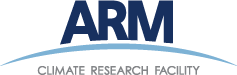

A Py-ART é uma biblioteca de código aberto que fornece uma série de funcionalidades para leitura, processamento e visualização de dados de radares meteorológicos. Py-ART é usada pela comunidade do [Atmospheric Radiation Measurement (ARM)](https://www.arm.gov/)
para trabalhar com dados de radar e demais usuários da comunidade de radar em geral. A biblioteca oferece os seguintes recursos:

1. Leitura de formatos de dados de radar comuns, incluindo formatos nativos de diferentes fabricantes de radares.

2. Pré-processamento de dados, incluindo filtragem de ruído, correção de atenuação e interpolação.

3. Detecção de alvos meteorológicos, como precipitação, nuvens e tempestades.

4. Extração de parâmetros meteorológicos, como refletividade, velocidade radial e espectro de Doppler.

5. Visualização e plotagem de dados de radar em várias formas, incluindo imagens de refletividade, campos de vento e perfis verticais.

Para maiores informações sobre a biblioteca **Py-ART**:
- Pypi: https://pypi.org/project/arm-pyart/
- GitHub: https://github.com/ARM-DOE/pyart
- Documentação: https://arm-doe.github.io/pyart/
- Exemplos: https://arm-doe.github.io/pyart/examples/index.html
- Sites adicionais:
    1. https://openradarscience.org/erad2022/README.html
    2. https://openradarscience.org/
    3. https://github.com/mgrover1/ams-open-radar-2023
    4. https://github.com/mgrover1/erad2024/tree/main
    5. https://xarray.dev/blog/introducing-xradar
- Artigo: Helmus, J.J. & Collis, S.M., (2016). The Python ARM Radar Toolkit (Py-ART), a Library for Working with Weather Radar Data in the Python Programming Language. Journal of Open Research Software. 4(1), p.e25. DOI: http://doi.org/10.5334/jors.119

----

**An Open Source Library for Weather Radar Data Processing (Wradlib)**:

------


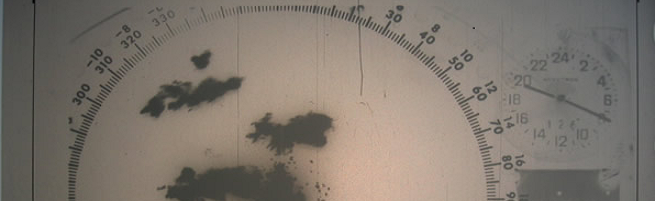

A Wradlib é uma biblioteca python que foi desenvolvida com a finalidade de processamento e análise de dados de radar meteorológico. Especificamente o foco da Wradlib é realizar processamento, leitura de direntes formatos, georeferenciamento, cálculo de precipitação, identificação e correção de fontes de erros (clutter e atenuação) e visualização de dados. Uma das principais características da wradlib é sua capacidade de corrigir o efeito de atenuação nos dados de radar.


Para maiores informações sobre a biblioteca **Wradlib**:
- Pypi: https://pypi.org/project/wradlib/
- GitHub: https://github.com/wradlib/wradlib
- Documentação: https://docs.wradlib.org/en/latest/
- Exemplos: https://docs.wradlib.org/en/latest/notebooks/plotting.html


----

Em resumo, a `Py-ART` é uma biblioteca mais abrangente e geral para processamento, visualização e análise de dados de radar meteorológico, enquanto a `Wradlib` é mais especializada em processamento e análise de dados de radar, com ênfase na correção de atenuação e no formato de dados ODIM H5. A escolha entre as duas bibliotecas depende das necessidades específicas do projeto e das funcionalidades desejadas. Tanto a `Py-ART` quanto a `Wradlib` têm comunidades ativas de usuários e desenvolvedores. No entanto, a `Py-ART` tem uma comunidade um pouco maior, sendo mais amplamente utilizada em diferentes aplicações, o que pode significar mais recursos disponíveis e um suporte mais abrangente.

----

Embora nessa disciplina utilizaremos apenas as bibliotecas `Py-ART` e `Wradlib` para tratar os dados de radar meteorológico, existem diversas outras bibliotecas para diferente finalidades para trabalhar com dados de radar, por exemplo:

---

1. [Pyrad - Python Radar Data Processing](https://github.com/MeteoSwiss/pyrad): framework de processamento de dados de radar em tempo real desenvolvido pela MeteoSwiss e MeteoFrance.

2. [PyDDA -A Pythonic Multiple Doppler Radar Wind Retrieval Package](https://github.com/openradar/PyDDA): pacote python para estimar vento em 3D (u,v,w) usando multíplos radares através de assimilação de dados 3D.


3. [Tobac - Tracking and Object-Based Analysis of Clouds](https://tobac.readthedocs.io/en/latest/): pacote python para rapidamente identificar, rastrear e analisar nuvens proveniente de diferentes tipos de dados em grade, tais como sáida produzidas por cloud-resolving model ou estimativa 2D dde dados de satelites.


4. [TINT Is Not TITAN (TINT) - A Package for Storm Cell Tracking In Python](https://github.com/mjucker/tintV2): pacote python desenvolvido para rastrear qualquer tipo de dado de entrada. Sua versão anterior [TINT](https://github.com/openradar/TINT/)

5. [TATHU - Tracking and Analysis of Thunderstorms](https://github.com/uba/tathu/): pacote python desenvolvido pelo CPTEC/INPE para rastrear e analisar ciclo de vida de Sistemas Convectivos através de imagens de satélite e radar meteorológico.

6. [Pysteps - Python framework for short-term ensemble prediction systems](https://github.com/pySTEPS/pysteps): pacote python usado para nowcasting de precipitação.

7. [Xradar](https://github.com/openradar/xradar): utilizado para transformar dados de radares para o formato do Xarray. [Maiores informações](https://docs.openradarscience.org/projects/xradar/en/stable/index.html).



#**AULA 02** - CONHECENDO OS DADOS DO RADAR COM A BIBLIOTECA Py-ART - `REALIZADA`

O objetivo da `Aula 02` é conhecermos as informações contidas no arquivo do radar. Nesse código da Aula 02 serão realizados os seguintes procedimentos:

 * Leitura do arquivo do radar
 * Variáveis disponíveis
 * Parâmetros do radar
 * Latitude, longitude e altura do radar
 * Tempo do volscan do radar  
 * Bins (range)
 * Azimutes  
 * Elevações  
 * Dados
 * Salvando os parâmetros do radar

##**a) Leitura do arquivo do radar**


 - Vamos abrir um arquivo do radar de Salesópolis para entendermos sobre as informações disponíveis do dado do radar. O nome do arquivo do radar possui as seguintes informações:
  1. `PNOVA2`: sigla do radar, indicando radar de Ponte Nova
  2. `20230218230002`: ano, mês, dia, hora, minuto e segundo
  3. `HDF5`: extensão do arquivo e indicação do formato HDF

In [ ]:
# nome do arquivo
filename = 'PNOVA2-20230218230002.HDF5'

- Baixando o arquivo do radar. Iremos baixar esse arquivo do radar diretamente do [GitHub](https://github.com/evmpython/CAT016_2025) da nossa disciplina. Para isto utilizaremos o comando do Linux denominado `wget`.

In [ ]:
!wget {url}raw/main/input/{filename}

- O **Py-ART** possui diversas funções para leitura de dados de radar:
    1. **pyart.io**
    2. **pyart.aux_io**



1. As funções básicas são denominadas de [**pyart.io**](https://arm-doe.github.io/pyart/API/generated/pyart.io.html#module-pyart.io): são funções para ler e escrever dados de radar de diversos formatos. Na maioria dos casos a função **pyart.io.read()** é utilizada. Em outros casos, funções específicas são utilizadas, como por exemplo a função **pyart.io.read_uf()**, utilizada para ler arquivos em formato UF.

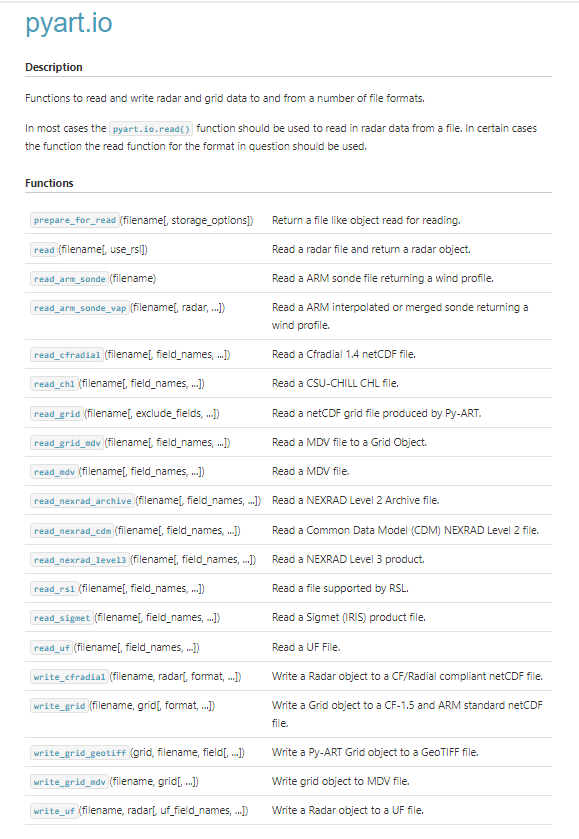

2. Além das funções básicas (**pyart.io**), nós temos as funções auxiliares para leitura dos arquivos de radar. São funções adicionais para leitura e escrita de formatos de arquivos de radar. Essas funções são denominadas de [**pyart.aux_io**](https://arm-doe.github.io/pyart/API/generated/pyart.aux_io.html). Por exemplo para lermos os dados ODIM, utilizaríamos a função [**pyart.aux_io.read_odim_h5**](https://arm-doe.github.io/pyart/API/generated/pyart.aux_io.read_odim_h5.html).

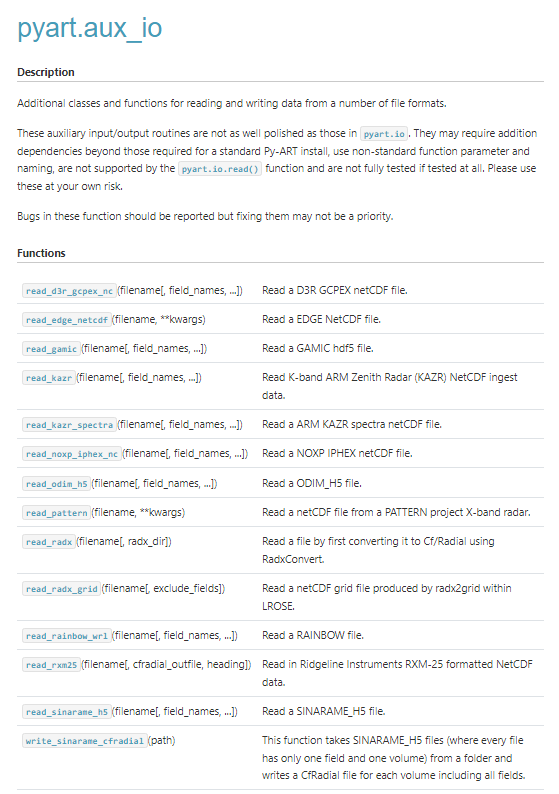

* Para ler os dados do radar de **Salesópolis** usaremos a função **[aux_io.read_gamic](https://arm-doe.github.io/pyart/API/generated/pyart.aux_io.read_gamic.html)**.

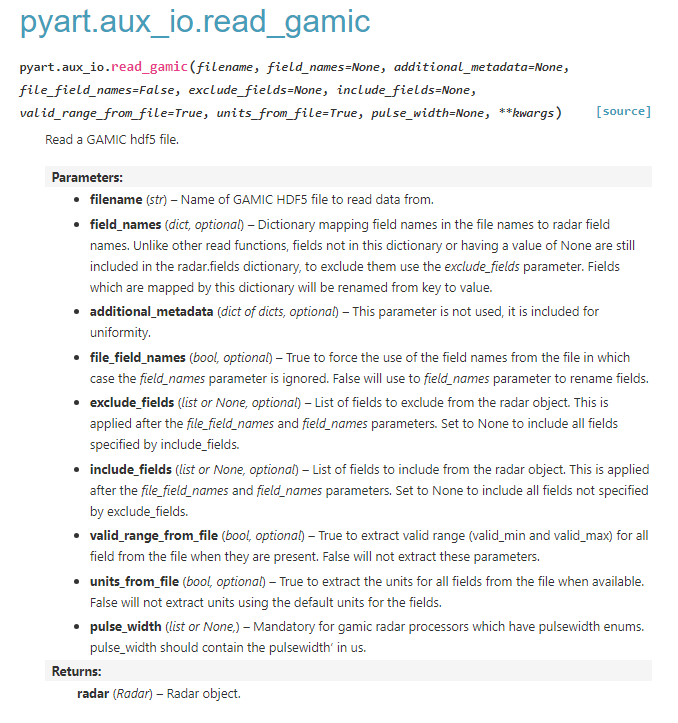

Vamos conferir quais argumentos têm a função `aux_io.read_gamic()`. Para isto basta colocarmos um sinal de interrogação depois do nome da função.

In [ ]:
# conferindo os argumentos e saídas da função
pyart.aux_io.read_gamic?

In [ ]:
# leitura do dado
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

In [ ]:
# mostrando a variável radar. Vejam que a variável "radar" é um objeto do pyart
radar

Para extrair as funções contidas no objeto `<pyart.core.radar.Radar>`, você pode usar a função `dir()` do Python. Isso listará todos os atributos e métodos (funções) disponíveis no objeto. Então vamos investigar as informações do objeto *radar*.

In [ ]:
# colocando as informações numa lista
lista = dir(radar)

# imprimindo na tela
print("\n".join(lista))

Obter ajuda sobre o objeto e seus métodos. Isso permitirá que você veja todas as funções disponíveis e como usá-las.

In [ ]:
help(radar)

Se precisar de mais detalhes sobre as informações contidas dentro de um método específico, você pode usar: `radar.nome_do_metodo`

In [ ]:
# extraindo as informações dentro do método chamado "longitude"
radar.longitude

##**b) Variáveis disponíveis**


 - Cada radar pode oferecer diferentes variáveis. Poir exemplo, o radar de Salesópolis é um radar Banda-S (alcance de 240 km) de dupla polarização e fornece ao todo `nove variáveis`.

In [ ]:
# exibindo as chaves dos campos do objeto radar
radar.fields.keys()

As seguintes variáveis são fornecidas pelo radar de Salesópolis:

---

1.  `corrected_reflectivity`:
 - Refletividade corrigida para extração de clutter (expressa em dBZ). Possui relação com o tamanho e quantidade de hidrometeoros.

---

2.  `reflectivity`:
 - Refletividade **não** corrigida (expressa em dBZ). Possui relação com o tamanho e quantidade de hidrometeoros.

---

3.  `corrected_velocity`:  
 - Velocidade radial corrigida (expressa em m/s). Possui relação com a velocidade radial dos hidrometeoros.

---

4.  `spectrum_width`:
 - Largura de espectro (expressa em m/s). Mostra a variabilidade da velocidade doppler em um determinado volume iluminado do radar. Quanto maior o valor, maior a variabilidade das velocidades de cada hidrometeoro dentro do volume iluminado, ou seja, maior a turbulência. Por exemplo, Mesociclones em supercélulas, tornados e tempestades estariam associados a valores altos de largura de espectro.

---

5.  `corrected_differential_reflectivity`:
 - Refletividade diferencial corrigida (expressa em dB), conhecida como ZDR. Possui relação com a orientação, grau de achatamento dos hidrometeoros.

---

6.  `corrected_differential_phase`:
 - Fase diferencial corrigida (expressa em graus). Representa a diferença de fase entre a onda polarizada horizontal e vertical da radiação.

---


7.  `differential_phase`:
 - Fase diferencial **não** corrigida (expressa em graus). Representa a diferença de fase entre a onda polarizada horizontal e vertical da radiação.

---

8.  `specific_differential_phase`:
 - Fase diferencial específica (expressa em graus/km), conhecida como KDP. Possui relação com a orientação, grau de achatamento e concentração dos hidrometeoros.

---

9.  `cross_correlation_ratio`: coeficiente de correlação (adimensional), conhecida como $\rho_{HV}$. Possui relação com grau de mistura dos hidrometeoros, fase das partículas (líquida ou gelo) e diversidade de formatos e orientações.
---

Maiores informações sobre a teoria de radares meteorológicos e variáveis polarimétricas, podem ser encontradas nos seguintes livros:
1. RINEHART,  R.  E. **Radar  for  meteorologists**. 5  ed.:  Rinehart  Publications, 2010.
2. BRINGI,  V.;  CHANDRASEKAR,  V. **Polarimetric  doppler  weather  radar: principles and applications**. 5°ed.: Cambridge University Press, 2001, 636 p



##**c) Parâmetros do radar**

O radar possui diversos parâmetros, como: Frequência, Pulse Repetition Frequency (PRF), largura do feixe e etc. Todas estas informações podem ser acessadas no objeto `radar` através do método `instrument_parameters`.

In [ ]:
# lembrando os métodos contidos no objeto "radar"
dir(radar)

In [ ]:
# mostra as informações disponíveis
radar.instrument_parameters.keys()

In [ ]:
# outra forma se mostrar as informações, seria:
radar.instrument_parameters

Vamos acessar as informações sobre a `frequência da radiação` do feixe do radar.

In [ ]:
radar.instrument_parameters['frequency']

Para transformar a frequência em comprimento de onda, basta dividir a velocidade da luz pelo valor da frequência. O resultado será em metros. Para transformar para centímetros basta multiplicarmos o resultado por 100.

In [ ]:
# comprimento de onda em metros (m)
comprimento_onda_m = 3e+08 / float(radar.instrument_parameters['frequency']['data'])
comprimento_onda_m

In [ ]:
# comprimento de onda em centímetros (cm)
comprimento_onda_cm = comprimento_onda_m * 100.
comprimento_onda_cm

Veja que temos um dicionário. Iremos salvar a frequência da radiação na variável `radar_frequency`.

In [ ]:
# frequência da radiação do radar
radar_frequency = radar.instrument_parameters['frequency']['data'][0]
radar_frequency

Vamos acessar as informações sobre a largura do feixe.

In [ ]:
# largura do feixe do radar em graus
radar.instrument_parameters['radar_beam_width_h']

Veja que temos um dicionário. Iremos salvar o ângulo de abertura do feixe na variável `radar_beam_width`.

In [ ]:
radar_beam_width = radar.instrument_parameters['radar_beam_width_h']['data'][0]
radar_beam_width

##**d) Latitude, longitude e altura do radar**

In [ ]:
# mostrando as chaves da "latitude"
radar.latitude.keys()

In [ ]:
# vejam que a latitude é um dicionário (ie, é estruturada na forma "chave": "valor")
radar.latitude

In [ ]:
# mostrando o valor da chave "long_name"
radar.latitude['long_name']

In [ ]:
# vejam que a longitude é um dicionário (ie, "chave": "valor")
radar.longitude

In [ ]:
# extrai a latitude e longitude do radar. "Data" é um array, portanto precisamos indicar qual posição queremos.
# no caso queremos a primeira, porém ele só possui um valor.
lat_radar = radar.latitude['data'][0]
lon_radar = radar.longitude['data'][0]
alt_radar = radar.altitude['data'][0]

print('O valor da latitude (graus) =', lat_radar)
print('O valor da longitude (graus) =', lon_radar)
print('Altura(m) =', radar.altitude['data'][0])

##**e) Tempo do volscan do radar**

In [ ]:
# vejam que o "time" é um dicionário (ie, "chave": "valor")
radar.time

In [ ]:
# tempo inicial do radar em segundos desde o inicio do scan do radar
radar.time['units']

In [ ]:
# tempo final do radar em segundos desde o inicio do scan do radar
radar.time['data'][-1]

In [ ]:
print('Data imagem do radar=', pyart.util.datetime_from_grid(radar))
print('Unidades do tempo=', radar.time['units'])
print('Início do volcan=', num2date(radar.time['data'][0], radar.time['units'] ))
print('Fim do volcan=', num2date(radar.time['data'][-1], radar.time['units'] ))

In [ ]:
# extrai a data inicial e final do scan em no formato "cftime._cftime.DatetimeGregorian"
data_ini = num2date(radar.time['data'][0], radar.time['units'] )
data_end = num2date(radar.time['data'][-1], radar.time['units'] )

# extrai ano,mes,dia,hora,minuto e segundos
print(data_ini.year, data_ini.month, data_ini.day, data_ini.hour, data_ini.minute, data_ini.second)
print(data_end.year, data_end.month, data_end.day, data_end.hour, data_end.minute, data_end.second)

In [ ]:
# extra a data da imagem
ano = str(pyart.util.datetime_from_grid(radar).year)
mes = str(pyart.util.datetime_from_grid(radar).month).zfill(2)
dia = str(pyart.util.datetime_from_grid(radar).day).zfill(2)
hor = str(pyart.util.datetime_from_grid(radar).hour).zfill(2)
min = str(pyart.util.datetime_from_grid(radar).minute).zfill(2)

print(ano, mes, dia, hor, min)

##**f) Bins (range)**

In [ ]:
# quantidade de elevações
nsweeps = radar.nsweeps
nsweeps

In [ ]:
# quantidade TOTAL de bins do feixe
ngates = radar.ngates
ngates

In [ ]:
# quantidade TOTAL de azimutes
nrays = radar.nrays
nrays

In [ ]:
# exibindo as chaves de "range"
radar.range.keys()

In [ ]:
# vejam que o "range" é um dicionário (ie, "chave": "valor")
radar.range

In [ ]:
# exibindo a chave "units" de range
radar.range['units']

In [ ]:
# exibindo a chave "data" de range
radar.range['data']

In [ ]:
radial_resolution = radar.range['meters_between_gates']
radial_resolution

##**g) Azimutes**

In [ ]:
# resolução ângular azimutal
radar.ray_angle_res

In [ ]:
# informação apenas da resolução angular azimutal (em graus)
ray_angle_res = radar.ray_angle_res['data'][0]
ray_angle_res

In [ ]:
# exibindo as chaves de "azimuth"
radar.azimuth.keys()

In [ ]:
# vejam que o "azimuth" é um dicionário (ie, "chave": "valor")
radar.azimuth

In [ ]:
# exibindo a chave "units" de azimuth
radar.azimuth['units']

In [ ]:
# quantidade TOTAL de azimutes do dado volumétrico
len(radar.azimuth['data'])

In [ ]:
# exibindo a chave "data" de azimuth
radar.azimuth['data']

In [ ]:
# exibindo os 10 primeiros valores do azimuth
radar.azimuth['data'][0:10]

In [ ]:
# exibindo o formato do array de azimute
print('Total de azimutes=', radar.azimuth['data'].shape)

##**h) Elevações**

In [ ]:
# vejam que o "sweep" (=elevações) é um dicionário (ie, "chave": "valor")
radar.sweep_start_ray_index

In [ ]:
print('Quantidade de elevações=', radar.sweep_start_ray_index['data'].shape)

In [ ]:
# vejam que o "fixed_angle" (elevações) é um dicionário (ie, "chave": "valor")
radar.fixed_angle

In [ ]:
sweeps =  list(radar.fixed_angle['data'])
print('Ângulos de elevação(graus)=', sweeps)

In [ ]:
# acessando o valor de um ângulo de elevação específico
radar.fixed_angle["data"][3]

In [ ]:
# verificando o número de azimutes para cada elevação

#=8
nsweeps = radar.nsweeps

# =2881
total_azimuths = radar.azimuth['data'].shape[0]

# [0, 360, 720, 1080, 1440, 1800, 2160, 2521, 2881]
index_azimuths = radar.sweep_start_ray_index['data'].tolist()

index_azimuths.append(total_azimuths)

# loop nas elevações
for i in range(nsweeps):

  # 360 - 0
  # 1080 - 720
  # 1440 - 1080
  # ....
  print('Numero de azimutes da elevacao ' + str(i) + ': ' + str(index_azimuths[i+1] - index_azimuths[i]))

##**i) Dados**

- Repare que a variável **radar.fields['reflectivity']['data']** é uma matriz de **2880 azimutes** por **960 bins**.
- Ou seja **2880** / **360** azimutes = **8** elevações

In [ ]:
# os dados estão alocados numa matriz de 2 dimensões (ie, array de 2 dimensões do numpy), frequentemente mascarado.
print('Dimensão dos dados de refletividade=', radar.fields['reflectivity']['data'].shape)
print('Unidade de refletividade=', radar.fields['reflectivity']['units'])

print('Máxima refletividade=', radar.fields['reflectivity']['data'].max())
print('Minima refletividade=', radar.fields['reflectivity']['data'].min())

In [ ]:
# exibindo os dados: os dados são salvos numa matriz (array, "data") de duas dimensões (azimutes, bins).
# além disso possui uma mascara para os dados ("mask")
radar.fields['reflectivity']['data']

In [ ]:
# latitudes e longitudes dos dados. É a lat e lon de cada bin do feixe do radar.
lats = radar.gate_latitude
lons = radar.gate_longitude

Repare que **lons** é um dicionário.

In [ ]:
# exibe os valores das longitudes
print(lons)

In [ ]:
# acessando o long_name
lons['long_name']

In [ ]:
# acessando o shape das longitudes
lons['data'].shape

In [ ]:
# acessando os valores das longitudes
lons['data']

In [ ]:
# definindo a extensão dos dados em termos de latitude/longitude
lonmin = lons['data'].min()
lonmax = lons['data'].max()
latmin = lats['data'].min()
latmax = lats['data'].max()

print(lonmin, lonmax, latmin, latmax)

##**j) Salvando os parâmetros do radar**

In [ ]:
#-----------------------------------------------------------------------------------
#        Obtêm as informações do radar a partir do dado bruto (HDF5)
#-----------------------------------------------------------------------------------
def get_info_radar(radar):

    """
    Obtêm as informações dos dados do radar

    Parâmetros de entrada:
                           radar (object): objeto do pyart

    Parâmetros de saída:
                         dic (dicionário): informações do radar, como:
                           date_start(list): ano, mês, dia hora, minuto inicial do scan do radar
                           date_end(list): ano, mês, dia hora, minuto final do scan do radar
                           lon_radar(float): longitude do radar em graus
                           lat_radar(float): latitude do radar em graus
                           alt_radar(float): altitude do radar em metros
                           radar_frequency(float): frequência do radar em Hz
                           radar_beam_width(float): largura do feixe em graus
                           nsweeps(int): quantidade de elevações
                           sweeps(list): ângulos de elevação em graus
                           nrays(list): quantidade de azimutes para cada elevação
                           ngates(int): quantidade de bins
                           radial_resolution(float): resolução radial do radar em metros
                           ray_angle_res(float): resolução azimutal em graus
                           lonmin(float): longitude mínima da matriz de dados
                           lonmax(float): longitude máxima da matriz de dados
                           latmin(float): latitude mínima da matriz de dados
                           latmax(float): latitude máxima da matriz de dados
                           variables(list): variáveis disponíveis

    Exemplo:
             dic = get_info_radar(radar)
    """

    # importa biblioteca de datas
    from netCDF4 import num2date

    # campos disponíveis
    variaveis = radar.fields.keys()

    # latitude e longitude do radar
    lon_radar, lat_radar, alt_radar = radar.longitude['data'][0], radar.latitude['data'][0], radar.altitude['data'][0]

    # informações sobre o tempo
    data_ini = num2date(radar.time['data'][0], radar.time['units'] )
    data_end = num2date(radar.time['data'][-1], radar.time['units'] )

    # extrai o ano, mes dia, hora e minuto inicial da imagem
    anoi, mesi, diai, hori, mini, segi = str(data_ini.year), str(data_ini.month).zfill(2), str(data_ini.day).zfill(2), str(data_ini.hour).zfill(2), str(data_ini.minute).zfill(2), str(data_ini.second).zfill(2)
    anof, mesf, diaf, horf, minf, segf = str(data_end.year), str(data_end.month).zfill(2), str(data_end.day).zfill(2), str(data_end.hour).zfill(2), str(data_end.minute).zfill(2), str(data_end.second).zfill(2)

    # frequência do radar
    radar_frequency = radar.instrument_parameters['frequency']['data'][0]

    # comprimento de onda em metros
    comprimento_onda_m = 3e+08 / float(radar.instrument_parameters['frequency']['data'])

    # comprimento de onda em centímetros
    comprimento_onda_cm = comprimento_onda_m * 100.

    # largura do feixe
    radar_beam_width = radar.instrument_parameters['radar_beam_width_h']['data'][0]

    # quantidade TOTAL de bins do feixe
    ngates = radar.ngates

    # quantidade de elevações
    nsweeps = radar.nsweeps

    # quantidade de azimutes por elevação
    total_azimuths = radar.azimuth['data'].shape[0]
    index_azimuths = radar.sweep_start_ray_index['data'].tolist()
    index_azimuths.append(total_azimuths)
    qte_azim = [index_azimuths[i+1] - index_azimuths[i] for i in range(nsweeps)]

    # resolução radial
    radial_resolution = radar.range['meters_between_gates']

    # informação apenas da resolução ângulo azimutal
    ray_angle_res = radar.ray_angle_res['data'][0]

    # ângulos de elevação
    sweeps =  radar.fixed_angle['data']
    sweeps = [float(i) for i in sweeps]

    # definindo a extensão dos dados em termos de latitude/longitude
    lats = radar.gate_latitude
    lons = radar.gate_longitude
    lonmin = lons['data'].min()
    lonmax = lons['data'].max()
    latmin = lats['data'].min()
    latmax = lats['data'].max()

    # coloca as variáveis num dicionário
    dic = {
            'date_start(year,month,day,hour,minute)': [anoi, mesi, diai, hori, mini],
            'date_end(year,month,day,hour,minute)': [anof, mesf, diaf, horf, minf],
            'lon_radar(degree)': float(lon_radar),
            'lat_radar(degree)': float(lat_radar),
            'alt_radar(meters)': float(alt_radar),
            'comprimento_onda(cm)': float(comprimento_onda_cm),
            'radar_beam_width(degree)': float(radar_beam_width),
            'nsweeps(#)': int(nsweeps),
            'sweeps(degree)': list(sweeps),
            'nrays(#)': qte_azim,
            'ngates(#)': ngates,
            'radial_resolution(meters)': float(radial_resolution),
            'ray_angle_res(degree)': float(ray_angle_res),
            'lonmin(degree)': float(lonmin),
            'lonmax(degree)': float(lonmax),
            'latmin(degree)': float(latmin),
            'latmax(degree)': float(latmax),
            'variables': list(variaveis)
           }

    return dic

In [ ]:
# processa a função que extrai as infomações do dado do radar
dic = get_info_radar(radar)

# salva arquivo
with open(f'{diretorio}/output/Aula_02_info_radar.csv', 'w') as f:
    for key in dic.keys():
        f.write("%s= %s\n"%(key, dic[key]))

In [ ]:
# mostra as informações do radar na tela
dic

In [ ]:
dic['lon_radar(degree)']

#**AULA 03** - ESTRATÉGIA DE VARREDURA DO RADAR - `REALIZADA`

O objetivo da `Aula 03` é plotarmos e analisarmos a estratégia de varredura do radar. Plotar a estratégia de varredura de um radar significa analisar como que os feixes do radar variam em função da distância para cada ângulo de elevação do feixe. Para isso utilizaremos a biblioteca Wradlib para plotar a estatégia do radar.

Especificamente usaremos a função **vis.plot_scan_strategy** da biblioteca Wralib. Mais informações sobre essa função clique [aqui](https://docs.wradlib.org/en/stable/generated/wradlib.vis.plot_scan_strategy.html). O seguinte procedimento sera realizado nessa aula:

 * Leitura do dado do radar

 * Extração das informações que serão utilizadas na função `wradlib.vis.
 plot_scan_strategy`. Precisamos definir os seguintes parâmetros:
  - `ranges`: distância de cada bin ao radar [m]
  - `sweeps`: ângulos de elevação [graus]
  - `sitecoords`: localização do radar (longitude, latitude, altitude) [graus, graus, m]
  - `beamwidth`: largura do feixe [graus]
  - `vert_res`: resolução vertical [m]
  - `maxalt`: máxima altitude [m]
  - `range_res`: resolução horizontal [m]
  - `maxrange`: máxima distância [m]
  - `units`: unidade dos eixos [m] ou [km]
  

 * Plotagem da figura

##1 - Leitura dos dados

In [ ]:
# nome do arquivo
filename = 'PNOVA2-20230218230002.HDF5'

# baixa o arquivo do radar
!wget {url}raw/main/input/{filename}

# leitura do dado
radar = pyart.aux_io.read_gamic(f'/content/{filename}')
radar

##2 - Extrair do dado do radar as informações a serem utilizadas

In [ ]:
# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
lat_radar, lon_radar

In [ ]:
# altitude do radar
alt_radar = radar.altitude['data'][0]
alt_radar

In [ ]:
# ângulos de elevação
sweeps = list(radar.fixed_angle['data'])
sweeps

In [ ]:
# quantidade TOTAL de bins do feixe
ngates = radar.ngates
ngates

In [ ]:
# resolução radial
radial_resolution = radar.range['meters_between_gates']
radial_resolution

In [ ]:
# distância de cada bin ao radar em metros
ranges = np.arange(ngates) * radial_resolution
ranges

In [ ]:
# ângulo de abertura do feixe
radar_beam_width = radar.instrument_parameters['radar_beam_width_h']['data'][0]
radar_beam_width

In [ ]:
# coordenadas do radar (longitude, latitude, altitude)
sitecoords = (lon_radar, lat_radar, alt_radar)
sitecoords

##3 - Plota figura

In [ ]:
# cria moldura da figura
fig, ax = plt.subplots(1,1,figsize=(10,6))

# define estilo do gráfico
plt.style.use('bmh')

# plota figura
wrl.vis.plot_scan_strategy(ranges,
                           sweeps,
                           sitecoords,
                           beamwidth=radar_beam_width,
                           vert_res = 1000.,
                           maxalt = 15000.,
                           range_res = 10000.,
                           maxrange = 200000.,
                           units='km',
                           ax=ax)

# título
ax.set_title('Estratégia do Radar de São Paulo')

# nomes dos eixos X e Y
ax.set_xlabel('Distância (km)')
ax.set_ylabel('Altura (km)')

# mantém apenas os marcadores a cada 5 posições, reduzindo a quantidade de marcas exibidas no eixo X
ax.set_xticks(ax.get_xticks()[::5])

# limites dos eixos X e Y
ax.set_xlim(0., 200000.)
ax.set_ylim(0., 15000.)

# grade da figura
ax.grid()

# não plota os "minorticks" (menores marcadores)
ax.minorticks_off()

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_03_estrategia_varredura_do_radar.jpg',
            dpi=300,
            bbox_inches='tight')

#**AULA 04** - PLAN POSITION INDICATOR (PPI) - `REALIZADA`

Antes de plotarmos o mapa de PPI, precisamos ler o nosso dado do radar. Conforme visto nas aulas anteriores usaremos a função `aux_io.read_gamic`.

In [ ]:
# nome do arquivo
filename = 'PNOVA2-20230218230002.HDF5'

# baixa o arquivo do radar
!wget {url}raw/main/input/{filename}

# leitura do dado
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

In [ ]:
# verificando as variáveis existentes no arquivo do radar
variaveis_do_radar = radar.fields.keys()

# mostra os dados
pd.DataFrame(variaveis_do_radar)

In [ ]:
# ângulos de elevação
sweeps =  list(radar.fixed_angle['data'])
sweeps

Para plotar um mapa através do Py-ART utilizaremos o objeto   [**RadarMapDisplay**](https://arm-doe.github.io/pyart/API/generated/pyart.graph.RadarMapDisplay.html) para plotar mapas geográficos. O dado de entrada do RadarMapDisplay é o objeto radar que obtivemos ao ler os dados do radar, o qual denominamos de `radar` [Exemplo: `radar = pyart.aux_io.read_gamic('PNOVA2-20230218235502.HDF5')`].

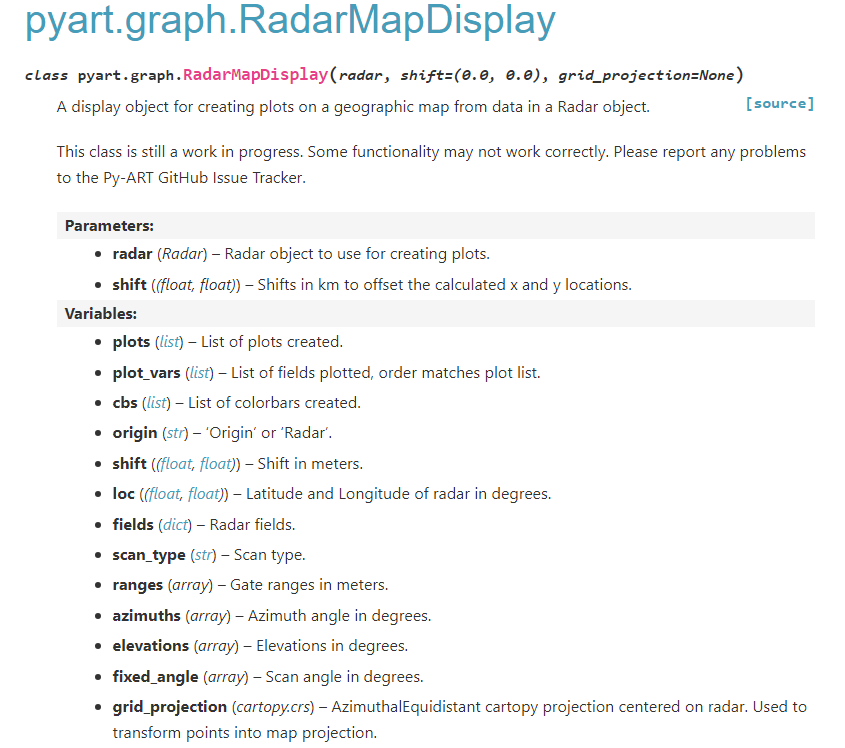

In [ ]:
# cria moldura da figura
fig = plt.figure(figsize=[10, 10])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

A partir do objeto `display` criado, precisamos indicar agora qual o tipo de gráfico que gostaríamos de criar. No nosso caso queremos plotar um mapa de **Plan Position Indicatior (PPI)** para uma determinada elevação, e para isto usaremos a função denominada **plot_ppi_map()**. Mas antes vamos verificar os atributos dessa função:

In [ ]:
# verificando os atributos da função
display.plot_ppi_map?

Iremos plotar o campo de refletividade. Para isso devemos inserir o nome da variável `corrected_reflectivity` na função **plot_ppi_map()**.

In [ ]:
# cria moldura da figura
fig = plt.figure(figsize=[10, 10])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# plota o mapa
display.plot_ppi_map('corrected_reflectivity')

- Repare que o nosso gráfico não ficou científicamente elegante. Observamos que por padrão plota-se o PPI da primeira elevação e o mapa de cores padrão do Matplotlib. Então, vamos customizar nosso gráfico. Para isto iremos adicionar os seguintes argumentos:

    1. `sweep` = **3**: Quarta elevação (Lembre-se que o índice do Python começa em 0!).
    2. `vmin` = **-20**: Mínimo valor para o campo/barra de cor de refletividade.
    3. `vmax` = **60**: Maxímo valor para o campo/barra de cor de refletividade.
    4. `projection` = **ccrs.PlateCarree()**: Sistema de coordenadas latitude/longitude do Cartopy.
    5. `cmap` = **'HomeyerRainbow'**: Paleta de cor fornecida pelo Py-ART.

In [ ]:
# lembrando que os ângulos de elevação são:
sweeps

In [ ]:
# cria moldura da figura
fig = plt.figure(figsize=[10, 10])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep = 3,
                     vmin = -20,
                     vmax = 60,
                     projection = ccrs.PlateCarree(),
                     cmap = 'HomeyerRainbow')

- Existem diversas paletas de cores provenientes do Matplotlib e Py-ART, e você pode utilizar aquela que melhor se adequa ao seu objetivo. Maiores informações sobre as paletas de cores disponíveis no Py-ART acesse o [tutorial](https://arm-doe.github.io/pyart/examples/plotting/plot_choose_a_colormap.html#id1). Por exemplo, vamos testar uma paleta de cores em que os valores acima de 20 dBZ são destacados com cores quentes, através do uso da paleta de cores denominada **BuOr12**.

- Além disso podemos mudar a orientação da barra de cores de *vertical* para *horizontal*, usando o parâmetro `colobar_orient='horizontal'`. Mais informações sobre os parâmetros usados na barra de cores, acessar [aqui](https://arm-doe.github.io/pyart-docs-travis/API/generated/pyart.graph.RadarMapDisplay.plot_colorbar.html).

In [ ]:
# cria moldura da figura
fig = plt.figure(figsize=[10, 10])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep=3,
                     vmin=-20,
                     vmax=60,
                     projection=ccrs.PlateCarree(),
                     cmap='BuOr12',
                     colorbar_orient='horizontal')

Agora vamos deixar o nosso gráfico o mais customizado possível.

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 0 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# definindo a projeção do mapa
projection = ccrs.PlateCarree(central_longitude=lon_radar)

# cria moldura da figura
fig = plt.figure(figsize=[8,5])

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep=level,
                     vmin=0,
                     vmax=70,
                     fig=fig,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=projection,
                     resolution='10m',
                     cmap='NWSRef',
                     colorbar_label='Refletividade (dBZ)',
                     colorbar_orient='vertical',
                     title=f'PPI {str_level}$\degree$: {data} UTC')

# ajusta a posição da colorbar para ficar mais afastada
cbar = plt.gcf().axes[-1]                         # último eixo é normalmente a colorbar
cbar.set_position([0.80, 0.11, 0.08, 0.78])       # [left, bottom, width, height]
cbar.tick_params(which='minor', length=0)         # oculta minorticks visuais
cbar.yaxis.set_minor_locator(plt.NullLocator())   # remove localizador de minorticks

# plota as linhas transversais que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='X', label_text='radar', color='blue')

# plota aneis de distância
display.plot_range_rings([50, 240], ls='--', lw=1, col='gray')

# plota as linhas de latitudes e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

"""
# para deixar as coordenadas dentro do plot, basta descomentar o bloco a seguir
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xpadding = -5; gl.ypadding = -5
gl.ylabel_style = {'color': 'black', 'size': 6, 'weight': 'bold'}
gl.xlabel_style = {'color': 'black', 'size': 6, 'weight': 'bold'}
"""

# salva figura
plt.savefig(f'{diretorio}/output/Aula_04a_ppi_{str_level}graus_{data}.jpg', bbox_inches='tight', dpi=300)



---


**Realize as seguintes modificações:**
1.  Plote outros ângulos de elevação.


---




Ao analisar a área total do radar não temos o detalhamento de uma tempestade em específico. Para isso, precisaremos delimitar a latitude e longitude da região de interesse através do atributo `min_lon, max_lon, min_lat e max_lat` no objeto **plot_ppi_map()**.

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 0 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# definindo a projeção do mapa
projection = ccrs.PlateCarree(central_longitude=lon_radar)

# cria moldura da figura
fig = plt.figure(figsize=[8,5])

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep=level,
                     vmin=0,
                     vmax=70,
                     fig=fig,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=projection,
                     resolution='10m',
                     cmap='NWSRef',
                     colorbar_label='Refletividade (dBZ)',
                     min_lon=-46,
                     max_lon=-45,
                     min_lat=-24.2,
                     max_lat=-23.5,
                     title=f'PPI {str_level}$\degree$: {data} UTC')

# ajusta a posição da colorbar e remove os minorticks
cbar = plt.gcf().axes[-1]                         # último eixo é normalmente a colorbar
cbar.set_position([0.82, 0.14, 0.06, 0.70])       # reposiciona a barra # [left, bottom, width, height]
cbar.tick_params(which='minor', length=0)         # oculta minorticks visuais
cbar.yaxis.set_minor_locator(plt.NullLocator())   # remove localizador de minorticks

# plota as linhas transversais que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray')

# plota as linhas de latitudes e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# salva figura
plt.savefig(f'{diretorio}/output/Aula_04b_ppi_{str_level}graus_{data}.jpg',
            bbox_inches='tight',
            dpi=300)


---


**Realize as seguintes modificações:**
1.  Aproxime ainda mais a imagem, aplicando um zoom.


---

É muito comum querermos delimitar apenas regiões com valores de refletividade acima de um determinado valor. Para isso, podemos delimitar o valor mínimo (`vmin`) e máximo (`vmax`) e mascarar os valores que estão fora desse range de valores utilizando o atributo `mask_outside` com o valor **True**. Por exemplo, gostaríamos de analisar apenas ecos de radar com valores acima de `40 dBZ`.

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 0 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# definindo a projeção do mapa
projection = ccrs.PlateCarree(central_longitude=lon_radar)

# cria moldura da figura
fig = plt.figure(figsize=[8,5])

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep=level,
                     vmin=40,
                     vmax=70,
                     fig=fig,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=projection,
                     resolution='10m',
                     cmap='NWSRef',
                     colorbar_label='Refletividade (dBZ)',
                     min_lon=-46,
                     max_lon=-45,
                     min_lat=-24.2,
                     max_lat=-23.5,
                     mask_outside=True,
                     title=f'PPI {str_level}$\degree$: {data} UTC')

# ajusta a posição da colorbar e remove os minorticks
cbar = plt.gcf().axes[-1]                         # último eixo é normalmente a colorbar
cbar.set_position([0.82, 0.14, 0.06, 0.70])       # reposiciona a barra # [left, bottom, width, height]
cbar.tick_params(which='minor', length=0)         # oculta minorticks visuais
cbar.yaxis.set_minor_locator(plt.NullLocator())   # remove localizador de minorticks

# plota as linhas transversais que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray')

# plota as linhas de latitudes e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# salva figura
plt.savefig(f'{diretorio}/output/Aula_04c_ppi_{str_level}graus_{data}.jpg',
            bbox_inches='tight',
            dpi=300)


---


**Realize as seguintes modificações:**
1.  Aproxime ainda mais a imagem, aplicando um zoom.


---

#**AULA 05** - CONSTANT ALTITUDE PLAN POSITION INDICATOR (CAPPI) - `REALIZADA`

Para gerar o CAPPI usaremos os dados de todos PPI. Para isto usaremos uma função do Py-ART que transforma de PPI para CAPPI, conhecida como [map.grid_from_radars](https://arm-doe.github.io/pyart/API/generated/pyart.map.grid_from_radars.html). Vejam também a função [map.map_to_grid](https://arm-doe.github.io/pyart/API/generated/pyart.map.map_to_grid.html).

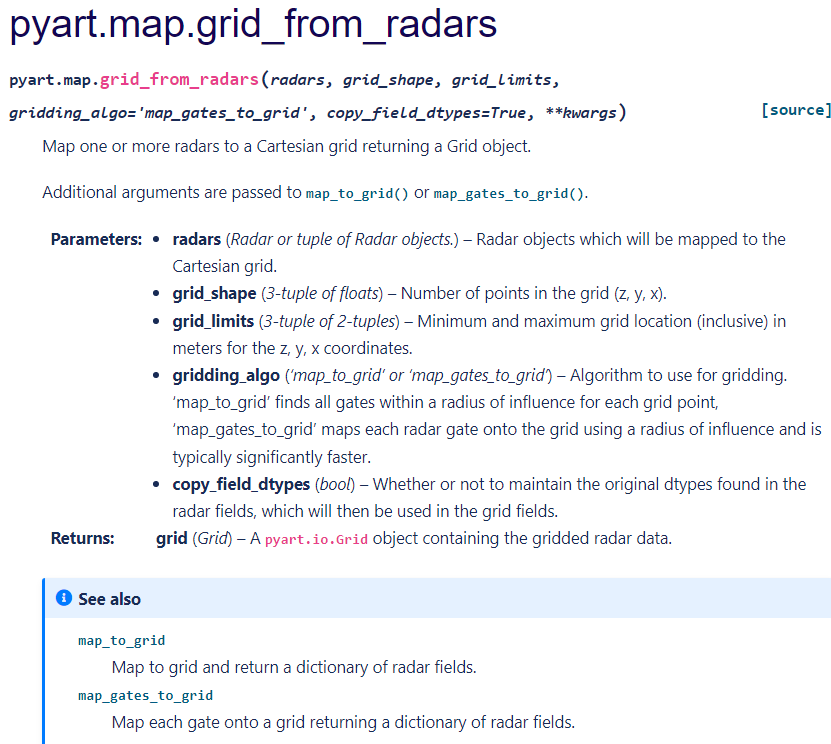

O Py-ART tem o objeto `grid` que possui características similares ao objeto `Radar`, exceto que os dados são alocados em **Cordenadas Cartesianas** ao invés de **Coordenadas da Antena do Radar**. Vamos acessar os parâmetros de entrada da função `Grid`.

In [ ]:
pyart.core.Grid?

In [ ]:
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude, e altitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
altitude = radar.altitude['data'][0]

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

# gera CAPPI
cappi = pyart.map.grid_from_radars(radar,
                                   grid_shape=(13, 500, 500),
                                   grid_limits=((3000.0 - altitude, 15000.0 - altitude),
                                                (-250000., 250000.),
                                                (-250000., 250000.)),
                                   grid_origin=(lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam',
                                   min_radius=1750.0,
                                   weighting_function='Nearest',
                                   fields=['corrected_reflectivity'])

In [ ]:
# mostra os campos disponiveis
cappi.fields.keys()

In [ ]:
# mostra o formato da variável "cappi"
cappi.fields['corrected_reflectivity']['data'].shape

In [ ]:
# mostra as informações sobre a refletividade
cappi.fields['corrected_reflectivity']

In [ ]:
# mostrando os dados do CAPPI de TODAS alturas
cappi.fields['corrected_reflectivity']['data']

- Gostaríamos de plotar de maneira simples o CAPPI de 3 km de altura da refletividade corrigida. Para plotarmos o mapa de CAPPI de uma determinada altura, criaremos um objeto do Py-ART denominado [GridMapDisplay](https://arm-doe.github.io/pyart-docs-travis/API/generated/pyart.graph.GridMapDisplay.html). A partir desse objeto criado utilizaremos a função [plot_grid](https://arm-doe.github.io/pyart-docs-travis/API/generated/pyart.graph.GridMapDisplay.plot_grid.html#pyart.graph.GridMapDisplay.plot_grid) para plotar o mapa de CAPPI. Mas antes vamos verificar os argumentos da função **graph.GridMapDisplay.plot_grid**.

In [ ]:
# conferindo os argumentos e saídas da função
pyart.graph.GridMapDisplay.plot_grid?

In [ ]:
# define o tamanho da figura
fig = plt.figure(figsize=(8, 7))

# define os eixos e projeção da figura
ax1 = plt.subplot(111, projection=ccrs.PlateCarree())

# monta um objeto "display" do Py-ART
display = pyart.graph.GridMapDisplay(cappi)

# corrige o nível do cappi levando em conta a altitude do radar
# para mostrar corretamente no título da figura
display.grid.z['data'] = display.grid.z['data'] + altitude

# plota o cappi
display.plot_grid("corrected_reflectivity",
                  level=0,
                  vmin=0,
                  vmax=70,
                  ax=ax1,
                  cmap='NWSRef')

Plotando o CAPPI de maneira mais completa

In [ ]:
# contador de tempo
%%time
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude, longitude do radar e altitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
altitude = radar.altitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                             GERA O CAPPI
#========================================================================================================================#
# gera CAPPI
cappi = pyart.map.grid_from_radars(radar,
                                   grid_shape=(13, 500, 500),
                                   grid_limits=((3000. - altitude, 15000. - altitude),
                                                (-250000., 250000.),
                                                (-250000., 250000.)),
                                   grid_origin=(lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam',
                                   min_radius=1750.0,
                                   weighting_function='Nearest',
                                   fields=['corrected_reflectivity'])

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define o tamanho da figura
fig = plt.figure(figsize=(10,7))

# define os eixos e projeção da figura
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# monta um objeto "display" do Py-ART
display = pyart.graph.GridMapDisplay(cappi)

# plota o cappi
level = 10

display.plot_grid("corrected_reflectivity",
                  level=level,
                  vmin=0,
                  vmax=70,
                  ax=ax,
                  cmap='NWSRef',
                  colorbar_label='Refletividade (dBZ)')

# ajusta a posição da colorbar e remove os minorticks
cbar = plt.gcf().axes[-1]                         # último eixo é normalmente a colorbar
cbar.set_position([0.80, 0.11, 0.08, 0.78])       # [left, bottom, width, height]
cbar.tick_params(which='minor', length=0)         # oculta minorticks visuais
cbar.yaxis.set_minor_locator(plt.NullLocator())   # remove localizador de minorticks

# aumenta fonte da colorbar
for label in cbar.get_yticklabels():  # se for colorbar vertical
    label.set_fontsize(15)

# tamanho da letra do nome da legenda
cbar.set_ylabel('Refletividade (dBZ)', fontsize=15)

# plotas as linhas passando pelo radar
display.plot_crosshairs(lon=lon_radar, lat=lat_radar)

# plota os aneis de distância do radar
evm_plota_aneis_em_geral([100, 250], lon_radar, lat_radar, 'black', label='Radar: 45 km')

# título da figura
altura = int(int(display.grid.z["data"][level]) + altitude)
plt.title(f'CAPPI {altura} m - Refletividade: {data}', fontsize=10)

# nome dos eixos x e y
ax.set_xlabel('Longitude ($\degree$)', fontsize=15)
ax.set_ylabel('Latitude ($\degree$)', fontsize=15)

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_05_cappi_{altura}m_{data}.jpg', dpi=300)
print(altura)


---


**Realize as seguintes modificações:**
1.  Plote o CAPPI para outras alturas.


---

#**AULA 06** - SEÇÃO TRANSVERSAL VERTICAL ATRAVÉS DO CAPPI - `REALIZADA`

Este script plota uma seção transversal ao longo de uma linha que conecta dois pontos no espaço. Teremos que informar a latitude e longitude do ponto 1 e ponto 2.

In [ ]:
# instala a biblioteca metpy
!pip install -q --upgrade metpy

`Reinicie o ambiente de execução:`

Depois de instalar o MetPy, você precisa reiniciar o `runtime (ambiente de execução)` para que as mudanças tenham efeito. No Google Colab, vá em  `Ambiente de execução` >  `Reinicar sessão` e clique em `Sim`. Além disso, execute novamente os  `Passos 1 ao 5 `.

In [ ]:
# mostrandos os atributos da função "retrieve.conv_strat_yuter"
pyart.graph.GridMapDisplay.plot_cross_section?

In [ ]:
# nome do arquivo
filename = 'PNOVA2-20230218230002.HDF5'

# baixa o arquivo do radar
!wget {url}raw/main/input/{filename}

# leitura do dado
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

In [ ]:
%%time
#========================================================================================================================#
#                                                LEITURA DADO DO RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude, longitude e altitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
altitude = radar.altitude['data'][0]

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                             GERA O CAPPI
#========================================================================================================================#
# gera CAPPI
cappi = pyart.map.grid_from_radars(radar,
                                   grid_shape=(13, 500, 500),
                                   grid_limits=((3000. - altitude, 15000. - altitude),
                                                (-250000., 250000.),
                                                (-250000., 250000.)),
                                   grid_origin=(lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam',
                                   min_radius=1750.0,
                                   weighting_function='Nearest',
                                   fields=['corrected_reflectivity'])

#========================================================================================================================#
#                                             DEFINE LOCAL DO CORTE VERTICAL
#========================================================================================================================#
# define o ponto inicial e final, usando (latitude, longitude)
start = (-24.77, -45.95)
end = (-23.59, -44.7)

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define o tamanho da figura
fig = plt.figure(figsize=(18, 6))

#==========================#
#     FIGURA 1: CAPPI
#==========================#
# moldura da figura
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())

# monta um objeto "display" do Py-ART
display = pyart.graph.GridMapDisplay(cappi)

# corrige o nível do cappi levando em conta a altitude do radar
# para mostrar corretamente no título da figura
display.grid.z['data'] = display.grid.z['data'] + altitude

# plota o cappi
display.plot_grid("corrected_reflectivity",
                  level=0,
                  vmin=0,
                  vmax=70,
                  ax=ax1,
                  cmap='NWSRef',
                  colorbar_label='Refletividade (dBZ)')

# plota o ponto inicial e final e a linha que conecta eles
ax1.scatter(start[1], start[0], color='red', label='Start')
ax1.scatter(end[1], end[0], color='black', label='End')
ax1.plot([start[1], end[1]], [start[0], end[0]], color="k", linestyle=":")
plt.legend(loc="upper right")

# nome dos eixos x e y
plt.xlabel('Longitude ($\degree$)')
plt.ylabel('Latitude ($\degree$)')

# título da figura
plt.title(f'CAPPI {int(display.grid.z["data"][0])} m: {data}', fontsize=15)
plt.title('a)', loc='left', fontsize=15)

#==========================#
#     FIGURA 2: Corte
#==========================#
# moldura da figura
# adiciona a seção transversal e seta o Eixo-X com a latitude (lat)
ax2 = plt.subplot(122)

# faz o plot
display.plot_cross_section("corrected_reflectivity",
                           start,
                           end,
                           x_axis="lat",
                           cmap='NWSRef',
                           vmin=0,
                           vmax=70,
                           steps=200,
                           colorbar_label='Refletividade (dBZ)')

# nome dos eixos x e y
plt.xlabel('Latitude do centro do grid ($\degree$)')
plt.ylabel('Distância acima do radar (km)')

# título da figura
plt.title('Seção Transversal', fontsize=15)
plt.title('b)', loc='left', fontsize=15)

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_06_vcut_{data}.jpg', dpi=300)


---


**Realize as seguintes modificações:**
1.  Realize um corte vertical numa região que tenha intensa convecção.


---

#**AULA 07** - VARIÁVEIS POLARIMÉTRICAS - `REALIZADA`

Baixando os dados

In [ ]:
# nome do arquivo
filename = 'PNOVA2-20230218230002.HDF5'

# baixa o arquivo do radar que esta no GitHub da nossa disciplina
!wget {url}raw/main/input/{filename}

Leitura do arquivo de radar

In [ ]:
# leitura do arquivo
radar = pyart.aux_io.read_gamic(f'/content/{filename}')
radar

Lembrando que temos as seguintes variáveis disponíveis no dado do radar:

In [ ]:
# exibindo as chaves dos campos do objeto radar
radar.fields.keys()

Lembrando o significado de cada variável fornecida pelo radar:

---

1.  `corrected_reflectivity`:
 - Refletividade corrigida para extração de clutter (expressa em dBZ). Possui relação com o tamanho e quantidade de hidrometeoros.

---

2.  `reflectivity`:
 - Refletividade **não** corrigida (expressa em dBZ). Possui relação com o tamanho e quantidade de hidrometeoros.

---

3.  `corrected_velocity`:  
 - Velocidade radial corrigida (expressa em m/s). Possui relação com a velocidade radial dos hidrometeoros.

---

4.  `spectrum_width`:
 - Largura de espectro (expressa em m/s). Mostra a variabilidade da velocidade doppler em um determinado volume iluminado do radar. Quanto maior o valor, maior a variabilidade das velocidades de cada hidrometeoro dentro do volume iluminado, ou seja, maior a turbulência. Por exemplo, Mesociclones em supercélulas, tornados e tempestades estariam associados a valores altos de largura de espectro.

---

5.  `corrected_differential_reflectivity`:
 - Refletividade diferencial corrigida (expressa em dB), conhecida como ZDR. Possui relação com a orientação, grau de achatamento dos hidrometeoros.

---

6.  `corrected_differential_phase`:
 - Fase diferencial corrigida (expressa em graus). Representa a diferença de fase entre a onda polarizada horizontal e vertical da radiação.

---


7.  `differential_phase`:
 - Fase diferencial **não** corrigida (expressa em graus). Representa a diferença de fase entre a onda polarizada horizontal e vertical da radiação.

---

8.  `specific_differential_phase`:
 - Fase diferencial específica (expressa em graus/km), conhecida como KDP. Possui relação com a orientação, grau de achatamento e concentração dos hidrometeoros.

---

9.  `cross_correlation_ratio`: coeficiente de correlação (adimensional), conhecida como $\rho_{HV}$. Possui relação com grau de mistura dos hidrometeoros, fase das partículas (líquida ou gelo) e diversidade de formatos e orientações.
---


Para plotarmos as demais variáveis do radar, basta mudarmos o nome da variável na função `.plot_ppi_map`. Por exemplo, iremos plotar o PPI da variável `Refletividade Diferencial Corrigida`.

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 0 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# setting projection
projection = ccrs.PlateCarree(central_longitude=lon_radar)

# cria moldura da figura
fig = plt.figure(figsize=[8,5])

# plota o mapa
display.plot_ppi_map('corrected_differential_reflectivity',
                     sweep=level,
                     vmin=-2,
                     vmax=6,
                     fig=fig,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=projection,
                     resolution='10m',
                     colorbar_label='Refletividade Diferencial (dB)',
                     mask_outside=False,
                     title=f'PPI {str_level}$\degree$: {data} UTC')

# ajusta a posição da colorbar para ficar mais afastada
cbar = plt.gcf().axes[-1]                         # último eixo é normalmente a colorbar
cbar.set_position([0.80, 0.11, 0.08, 0.78])       # [left, bottom, width, height]
cbar.tick_params(which='minor', length=0)         # oculta minorticks visuais
cbar.yaxis.set_minor_locator(plt.NullLocator())   # remove localizador de minorticks

# cross hairs
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray')

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota as linhas de latitudes e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# salva figura
plt.savefig(f'{diretorio}/output/Aula_07a_ppi_{str_level}graus_{data}.jpg',
            bbox_inches='tight',
            dpi=300)

Vamos plotar num mesmo mapa as quatro variáveis:
1. Refletividade Corrigida - ZH
2. Refletividade Diferencial Corrigida - ZDR
3. Fase Diferencial Específica - KDP
4. Coeficiente de Correlação - RhoHV

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 0 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# moldura da figura
fig = plt.figure(figsize=(10,8))

# cria o objeto display
display = pyart.graph.RadarMapDisplay(radar)

#==========================#
#       FIGURA 1: ZH
#==========================#
# moldura da figura
ax1 = plt.subplot(221, projection=ccrs.PlateCarree())

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep=level,
                     vmin=0,
                     vmax=70,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     resolution='10m',
                     colorbar_label='Refletividade (dBZ)',
                     mask_outside=False,
                     ax=ax1,
                     cmap='NWSRef')

# título da figura
plt.title('ZH', fontsize=15)
plt.title('a)', loc='left', fontsize=15)

# plota aneis de distância
display.plot_range_rings([100, 250], ax=ax1, col='gray', ls='--', lw=1)

# plota as linhas de latitudes e longitudes
ax = plt.gca()
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

#==========================#
#      FIGURA 2: ZDR
#==========================#
# moldura da figura
ax2 = plt.subplot(222, projection=ccrs.PlateCarree())

# plota ppi
display.plot_ppi_map('corrected_differential_reflectivity',
                     sweep=level,
                     vmin=-2,
                     vmax=6,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     resolution='10m',
                     colorbar_label='Refletividade Diferencial (dB)',
                     mask_outside=False,
                     ax=ax2)

# título da figura
plt.title('ZDR', fontsize=15)
plt.title('b)', loc='left', fontsize=15)

# plota aneis de distância
display.plot_range_rings([100, 250], ax=ax2, col='gray', ls='--', lw=1)

# plota as linhas de latitudes e longitudes
ax = plt.gca()
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

#==========================#
#     FIGURA 3: KDP
#==========================#
# moldura da figura
ax3 = plt.subplot(223, projection=ccrs.PlateCarree())

# plota ppi
display.plot_ppi_map('specific_differential_phase',
                     sweep=level,
                     vmin=-2,
                     vmax=6,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     resolution='10m',
                     colorbar_label='Fase Diferencial Específica ($\degree$/km)',
                     mask_outside=False,
                     ax=ax3)

# título da figura
plt.title('KDP', fontsize=15)
plt.title('c)', loc='left', fontsize=15)

# plota aneis de distância
display.plot_range_rings([100, 250], ax=ax3, col='gray', ls='--', lw=1)

# plota as linhas de latitudes e longitudes
ax = plt.gca()
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

#==========================#
#     FIGURA 4: COR
#==========================#
# moldura da figura
ax4 = plt.subplot(224, projection=ccrs.PlateCarree())

# plota ppi
display.plot_ppi_map('cross_correlation_ratio',
                     sweep=level,
                     vmin=0.7,
                     vmax=1,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     resolution='10m',
                     colorbar_label='Coeficiente de Correlação (#)',
                     mask_outside=False,
                     ax=ax4)

# título da figura
plt.title('RhoHV', fontsize=15)
plt.title('d)', loc='left', fontsize=15)

# plota aneis de distância
display.plot_range_rings([100, 250], ax=ax4, col='gray', ls='--', lw=1)

# plota as linhas de latitudes e longitudes
ax = plt.gca()
gl = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
#==========================#

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_07b_ppi_{str_level}graus_{data}.jpg',
            bbox_inches='tight',
            dpi=300)


---


**Realize as seguintes modificações:**
1. Mude a elevação.
2. Seteroze a figura através de um zoom na imagem.


---

#**AULA 08** - MÁXIMA REFLETIVIDADE - `REALIZADA`

O ojetivo dessa aula é plotar o MaxCAPPI da variável refletividade. Para isto utilizaremos a função do Py-Art denominada [plot_maxcappi](https://arm-doe.github.io/pyart/API/generated/pyart.graph.plot_maxcappi.html).

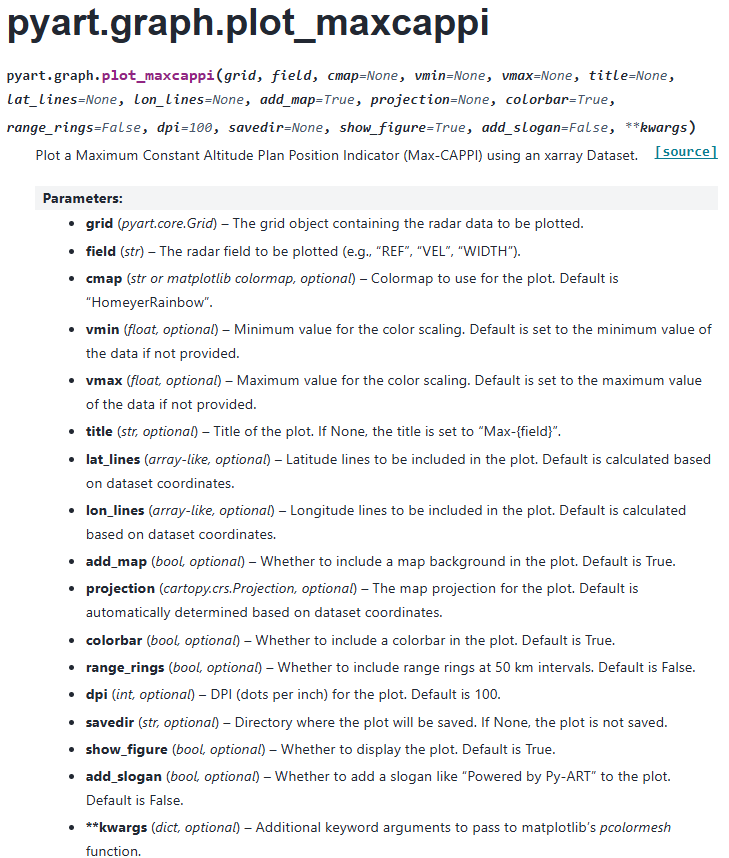

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
altitude = radar.altitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                             GERA O CAPPI
#========================================================================================================================#
# gera CAPPI
cappi = pyart.map.grid_from_radars(radar,
                                   grid_shape=(13, 500, 500),
                                   grid_limits=((3000. - altitude, 15000. - altitude),
                                                (-250000., 250000.),
                                                (-250000., 250000.)),
                                   grid_origin=(lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam',
                                   min_radius=1750.0,
                                   weighting_function='Nearest',
                                   fields=['corrected_reflectivity'])

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# cria o grid display
display = pyart.graph.GridMapDisplay(cappi)

# plota MaxCappi
display.plot_maxcappi(field="corrected_reflectivity",
                      cmap="NWSRef",
                      vmin=0,
                      vmax=70,
                      title='Máx. Refletividade',
                      range_rings=True,
                      savedir=f'{diretorio}/output')

Podemos adicionar um fundo na cor preto na figura. Para isto basta utilizar a função do Matplotlib denominada with `plt.style.context("dark_background")`.Vamos trocar também o mapa de cores para `HomeyerRainbow`.

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
altitude = radar.altitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                             GERA O CAPPI
#========================================================================================================================#
# gera CAPPI
cappi = pyart.map.grid_from_radars(radar,
                                   grid_shape=(13, 500, 500),
                                   grid_limits=((3000. - altitude, 15000. - altitude),
                                                (-250000., 250000.),
                                                (-250000., 250000.)),
                                   grid_origin=(lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam',
                                   min_radius=1750.0,
                                   weighting_function='Nearest',
                                   fields=['corrected_reflectivity'])

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# cria o grid display
display = pyart.graph.GridMapDisplay(cappi)

# adiciona fundo em cor preta na figura
with plt.style.context("dark_background"):

    # plota MaxCappi
    display.plot_maxcappi(field="corrected_reflectivity",
                          cmap="HomeyerRainbow",
                          vmin=0,
                          vmax=70,
                          title='Máx. Refletividade\nBlack',
                          range_rings=True,
                          savedir=f'{diretorio}/output')

#**AULA 09** - VENTO RADIAL - `REALIZADA`

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 0 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# define a projeção
projection = ccrs.PlateCarree(central_longitude=lon_radar)


# cria moldura da figura
fig = plt.figure(figsize=[8,5])

# plota o mapa
display.plot_ppi_map('corrected_velocity',
                     sweep=level,
                     vmin=-30,
                     vmax=30,
                     fig=fig,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=projection,
                     resolution='10m',
                     colorbar_label='Vento Radial (m/s)',
                     mask_outside=False,
                     title=f'PPI {str_level}$\degree$: {data} UTC')


# ajusta a posição da colorbar para ficar mais afastada
cbar = plt.gcf().axes[-1]                         # último eixo é normalmente a colorbar
cbar.set_position([0.80, 0.11, 0.08, 0.78])       # [left, bottom, width, height]
cbar.tick_params(which='minor', length=0)         # oculta minorticks visuais
cbar.yaxis.set_minor_locator(plt.NullLocator())   # remove localizador de minorticks

# plota as linhas transversais que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray')

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota as linhas de latitude e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# salva figura
plt.savefig(f'{diretorio}/output/Aula_09_ppi_{str_level}graus_vento_radial_{data}.jpg', bbox_inches='tight', dpi=300)


---


**Realize as seguintes modificações:**
1. Mude a elevação.
2. Seteroze a figura através de um zoom na imagem.


---

#**AULA 10** - ESTIMATIVA DA TAXA DE PRECIPITAÇÃO - `REALIZADA`

## Baixando os dados

In [ ]:
# nome do arquivo
filename = 'PNOVA2-20230218230002.HDF5'

# baixa o arquivo do radar que esta no GitHub da nossa disciplina
!wget {url}raw/main/input/{filename}

## 1) Usando as funções nativas do Py-ART.
- Existem diversas relações para calcular a precipitação através das variáveis fornecidas pelo radar. Usaremos como exemplo aquelas [fornecidas](https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.html) pelo Py-ART. Utilizaremos três relações:

    1. [retrieve.est_rain_rate_z](https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.est_rain_rate_z.html): estima a precipitação através de Lei de potência com a refletividade (`Z-R`).

    2. [retrieve.est_rain_rate_kdp](https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.est_rain_rate_kdp.html): estima a precipitação através da Lei de potência com o KDP (`KDP-R`).  
   
    3. [retrieve.est_rain_rate_zkdp](https://arm-doe.github.io/pyart-docs-travis/API/generated/pyart.retrieve.est_rain_rate_zkdp.html): estima a precipitação através da combinação da Lei de potência com a chuva-KDP e chuva-refletividade (`KDP-R` e `Z-R`).

In [ ]:
%%time
#========================================================================================================================#
#                                                LEITURA DADO DO RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude, longitude e altitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
altitude = radar.altitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                CALCULA PRECIPITAÇÃO
#========================================================================================================================#
# calcula a precipitação através de 3 métodos diferentes

# a) Z-R
chuva_zr = pyart.retrieve.est_rain_rate_z(radar,
                                          refl_field='corrected_reflectivity')

# b) KDP-R
chuva_dp = pyart.retrieve.est_rain_rate_kdp(radar, kdp_field='specific_differential_phase')

# c) Z-R e KDP-R
chuva_zdp = pyart.retrieve.est_rain_rate_zkdp(radar,
                                              refl_field='corrected_reflectivity',
                                              thresh_max=True,
                                              thresh=40)

# adiciona os campos criados na estrutura do objeto "radar"
radar.add_field('chuva_zr', chuva_zr)
radar.add_field('chuva_dp', chuva_dp)
radar.add_field('chuva_zdp', chuva_zdp)

#========================================================================================================================#
#                                                 GERA CAPPI
#========================================================================================================================#
# gera o cappi
cappi = pyart.map.grid_from_radars(radar, grid_shape=(1, 500, 500),
                                   grid_limits=((3000 - altitude, 3000 - altitude),
                                                (-250000., 250000.),
                                                (-250000, 250000.)),
                                   grid_origin = (lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam', min_radius=2000.0,
                                   weighting_function='Nearest')

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# moldura da figura
fig = plt.figure(figsize=(10,7))

# definição dos eixos da figura
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# cria o display
display = pyart.graph.GridMapDisplay(cappi)

# corrige o nível do cappi levando em conta a altitude do radar
# para mostrar corretamente no título da figura
display.grid.z['data'] = display.grid.z['data'] + altitude

# plota o mapa
display.plot_grid("chuva_dp",
                  level=0,
                  vmin=0,
                  vmax=100,
                  cmap='LangRainbow12',
                  ax=ax,
                  colorbar_label='Precipitação (mm/h)',
                  mask_outside=False)

# ajusta a posição da colorbar para ficar mais afastada
cbar = plt.gcf().axes[-1]                         # último eixo é normalmente a colorbar
cbar.set_position([0.80, 0.11, 0.08, 0.20])       # [left, bottom, width, height]
cbar.tick_params(which='minor', length=0)         # oculta minorticks visuais
cbar.yaxis.set_minor_locator(plt.NullLocator())   # remove localizador de minorticks

# nome dos eixos x e y
ax.set_xlabel('Longitude)')
ax.set_ylabel('Latitude')

# título da figura
plt.title(f'CAPPI {int(display.grid.z["data"][0])} m - Precipitação: {data}', fontsize=15)

# Plota os aneis de distancia do radar
evm_plota_aneis_em_geral([50,100,150,200,250], lon_radar, lat_radar, 'grey', label='')

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_10a_precipitacao_{data}.jpg', dpi=300)

Vamos verificar as variáveis existentes no CAPPI.

In [ ]:
cappi.fields.keys()

## 2) Calcula a precipitação utilizando uma relação Z-ZDR-KDP para radar Banda-S - [Ryzhkov et al (2005)](https://journals.ametsoc.org/view/journals/apme/44/4/jam2213.1.xml). Nessa formulação iremos utilizar Z, ZDR e KDP para estimar a precipitação, como explicado a seguir:

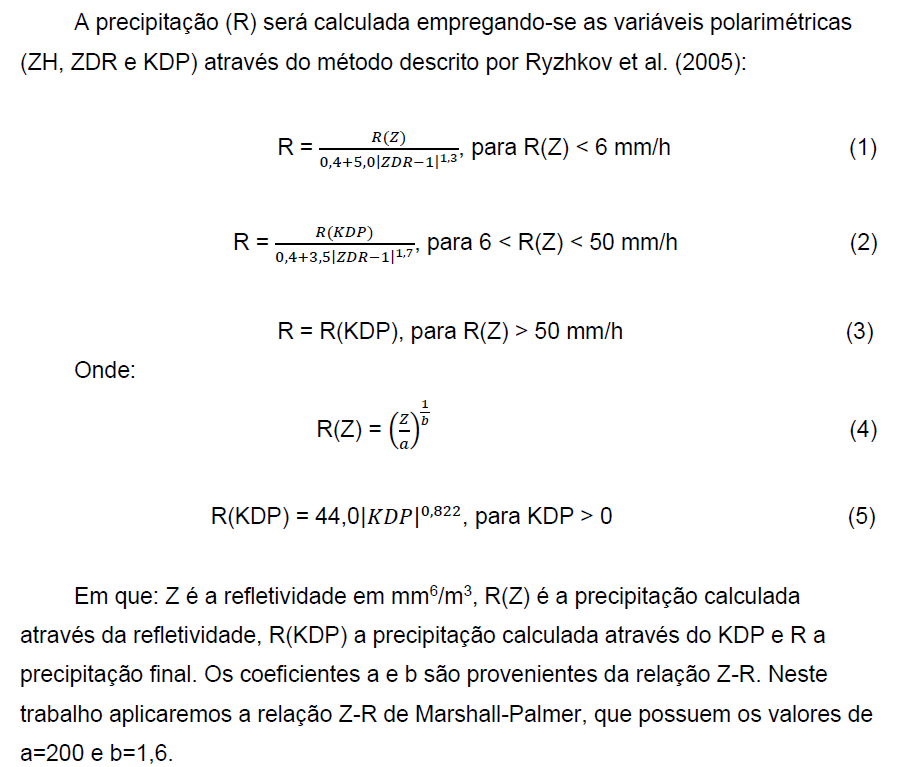

In [ ]:
%%time
#========================================================================================================================#
#                                                LEITURA DADO DO RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude, longitude e altitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
altitude = radar.altitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                CALCULA PRECIPITAÇÃO
#========================================================================================================================#
# guarda os campos de cada variável
refl = radar.fields['corrected_reflectivity']['data']
zdr = radar.fields['corrected_differential_reflectivity']['data']
kdp = radar.fields['specific_differential_phase']['data']

# chuva usando somente KDP
rkdp = 44.0 * np.ma.power(abs(kdp), 0.822)

# Marshall Palmer para Z-R
z = np.ma.power(10.0, refl/10) # transforma de dBZ para mm6/m3
r_zr = (np.ma.power(z/200, 1/1.6))

# copia o campo r_zr como matriz de saida
rain = r_zr

# agora verifica os limiares para uso com Z-ZDR-KDP
idx = np.where(r_zr <= 6)
rain[idx] = r_zr[idx] / (0.4 + 5.0 * np.ma.power(abs(zdr[idx] - 1), 1.3))

idx = np.where(r_zr > 6)
rain[idx] = rkdp[idx] / (0.4 + 3.5 * np.ma.power(abs(zdr[idx] - 1), 1.7))

idx = np.where(r_zr > 50)
rain[idx] = rkdp[idx]

#========================================================================================================================#
#                                                ADICIONA O CAMPO DE PRECIPITAÇÃO
#========================================================================================================================#
# insere o campo calculado no volume de dbz para poder calcular o cappi e retirar as informações que vem no cabeçalho do arquivo original.
# maiores informações sobre a função [.add_field_like](https://arm-doe.github.io/pyart-docs-travis/API/generated/pyart.core.Radar.add_field_like.html) do Py-ART.

radar.add_field_like('corrected_reflectivity', 'rain_rate', rain)
radar.fields['rain_rate']['units'] = 'mm/h'
radar.fields['rain_rate']['standard_name'] = 'Rain_Rate'
radar.fields['rain_rate']['long_name'] = 'Rain Rate'

#========================================================================================================================#
#                                                 GERA CAPPI
#========================================================================================================================#
cappi = pyart.map.grid_from_radars(radar, grid_shape=(1, 500, 500),
                                   grid_limits=((3000 - altitude, 3000 - altitude),
                                                (-250000., 250000.),
                                                (-250000, 250000.)),
                                   grid_origin = (lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam', min_radius=2000.0,
                                   weighting_function='Nearest')

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define o tamanho da figura
fig = plt.figure(figsize=(10,7))

# define os eixos e projeção da figura
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# monta um objeto "display" do Py-ART
display = pyart.graph.GridMapDisplay(cappi)

# corrige o nível do cappi levando em conta a altitude do radar
# para mostrar corretamente no título da figura
display.grid.z['data'] = display.grid.z['data'] + altitude

# plota o cappi - como temos 3 niveis, o nivel 0 = 2000, 1 = 3000 e 2 = 4000 m
display.plot_grid("rain_rate",
                  level=0,
                  vmin=0,
                  vmax=100,
                  cmap='LangRainbow12',
                  ax=ax,
                  colorbar_label='Precipitação (m/h)',
                  mask_outside=True)

# nomes dos eixos de longitude e latitude
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# plota os aneis de distância do radar
evm_plota_aneis_em_geral([50,100,150,200,250], lon_radar, lat_radar, 'black', label='')

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_10b_precipitacao_{data}.jpg', dpi=300)

In [ ]:
# mostra os campos disponíveis
pd.DataFrame(cappi.fields.keys())

#**AULA 11** - ACUMULADO DE PRECIPITAÇÃO - `AULA DE HOJE`

## 1) Declara funções

In [ ]:
# -------------------------------------------------------------------------------------
#                        Função: plota_aneis_distancia
# -------------------------------------------------------------------------------------
def plota_aneis_distancia(radii_km: list[float],
                          center_lon: float,
                          center_lat: float,
                          color: str,
                          label: str,
                          ax: 'matplotlib.axes.Axes',
                          line_style: str = '--',
                          line_width: float = 0.7
                          ) -> tuple[np.ndarray, np.ndarray]:

    """
    Plota círculos concêntricos de distância ao redor de um ponto central (ex: radar).

    Parameters
    ----------
    radii_km : list[float]
        Lista de raios em quilômetros para os círculos (ex: [50, 100, 150]).
    center_lon : float
        Longitude do centro em graus decimais (WGS84).
    center_lat : float
        Latitude do centro em graus decimais (WGS84).
    color : str
        Cor dos círculos (nome ou hexcode, ex: 'gray' ou '#808080').
    label : str
        Rótulo para a legenda (ex: 'Range: 100km').
    ax : matplotlib.axes.Axes
        Eixos matplotlib onde o plot será desenhado.
    line_style : str, optional
        Estilo da linha (default: '--' [tracejado]).
    line_width : float, optional
        Espessura da linha (default: 0.7).

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Arrays com (longitudes, latitudes) dos pontos dos círculos, shape (n_rings, 361).

    Examples
    --------
    >>> import matplotlib.pyplot as plt
    >>> fig, ax = plt.subplots()
    >>> lons, lats = plot_distance_rings(
    ...     radii_km=[50, 100],
    ...     center_lon=-45.97279,
    ...     center_lat=-23.600795,
    ...     color='gray',
    ...     label='Radar Range',
    ...     ax=ax
    ... )
    """

    # Validação de inputs
    if not isinstance(radii_km, (list, np.ndarray)):
        raise TypeError("radii_km deve ser uma lista ou array de valores numéricos")

    if not (-180 <= center_lon <= 180) or not (-90 <= center_lat <= 90):
        raise ValueError("Coordenadas fora do intervalo válido (lon: -180 a 180, lat: -90 a 90)")

    # Cálculo dos pontos
    origin = geopy.Point(center_lat, center_lon)
    n_points = 361  # Resolução angular (1 grau por ponto)
    lons = np.zeros((len(radii_km), n_points))
    lats = np.zeros((len(radii_km), n_points))

    for i, radius in enumerate(radii_km):
        for az in range(n_points):
            destination = distance.distance(kilometers=radius).destination(origin, az)
            lats[i, az], lons[i, az] = destination.latitude, destination.longitude

    # Plotagem
    for i, radius in enumerate(radii_km):
        ax.plot(lons[i, :],
                lats[i, :],
                color=color,
                label=label if i == 0 else None,  # Evita duplicar legendas
                linestyle=line_style,
                linewidth=line_width)

    return lons, lats

## 2) Descompacta a pasta que tem os arquivos por imagem do radar


### Definição do nome do arquivo

In [ ]:
# nome do arquivo
file = 'dados_radar_fcth_2023_02_18.tar.gz'

# nome do arquivo + diretório
file_path = f'{diretorio}/input/{file}'

# mostra o nome completo
print(file_path)

### Descompacta o arquivo

In [ ]:
%%time

# Diretório de destino para extração
destino = '/content/arquivos_do_radar'

# Cria o diretório de destino, se não existir
os.makedirs(destino+'/', exist_ok=True)

# Abrir o arquivo tar.gz
tar = tarfile.open(file_path)

# Listar os nomes dos arquivos dentro do tar
tar.getnames()

# Extrair todos os arquivos para o caminho desejado
tar.extractall(path=destino)

# Fechar o arquivo tar
tar.close()

In [ ]:
# lista dos arquivos
files0 = sorted(glob.glob(f'{destino}/PNOVA2*HDF5'))
len(files0)

## 3) Gera arquivo de precipitação para cada imagem do radar


### Iremos listar os arquivos que queremos processar

In [ ]:
#========================================================================================================================#
#                                                 DIRETÓRIOS
#========================================================================================================================#
# diretorio de entrada
dir_input = '/content/arquivos_do_radar'

# diretório de saída
dir_output = f'{diretorio}/output/arquivos_netcdf'

# cria a pasta "arquivos_netcdf" para salvar os arquivos netcdf
os.makedirs(f'{dir_output}/', exist_ok=True)

#========================================================================================================================#
#                                                 LISTA DOS ARQUIVOS
#========================================================================================================================#
files = sorted(glob.glob(f'{dir_input}/PNOVA2*HDF5')) # /content/arquivos_do_radar/PNOVA2-20230218000002.HDF5
files

### Para cada arquivo do radar produziremos um respectivo arquivo com os dados de precipitação.
- Os dados serão salvos num arquivo NETCDF, com as seguintes variáveis:
 1. Refletividade corrigida
 2. Estimativa de precipitação usando a refletividade: https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.est_rain_rate_z.html  
 3. Estimativa de precipitação usando o KDP: https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.est_rain_rate_kdp.html
 4. Estimativa de precipitação usando a Z e KDP: https://arm-doe.github.io/pyart-docs-travis/API/generated/pyart.retrieve.est_rain_rate_zkdp.html
 5. Estimativa de precipitação usando a Z, ZDR e KDP: https://journals.ametsoc.org/view/journals/apme/44/4/jam2213.1.xml     

   
- Para processar `1 hora` dos arquivos do radar demora aproximadamente `1min 36s` e para `24 horas` aproximadamente `23min 53s`.

In [ ]:
%%time
#========================================================================================================================#
#                                                 PROCESSAMENTO
#========================================================================================================================#
# Loop nos arquivos
for file in files:

    print('=============================================================================')
    print('PROCESSANDO ===>>', file)

    #--------------------------------------------------------------#
    #                  LEITURA DO ARQUIVO DO RADAR
    #--------------------------------------------------------------#
    # leitura do arquivo
    radar = pyart.aux_io.read_gamic(f'{file}')

    """
    Variáveis disponíveis do radar que podemos utilizar:
     1. corrected_reflectivity
     2. corrected_differential_reflectivity
     3. specific_differential_phase
     4. cross_correlation_ratio
     5. corrected_velocity
    """

    # extrai a data e horário do arquivo do radar
    ano = str(pyart.util.datetime_from_grid(radar).year)
    mes = str(pyart.util.datetime_from_grid(radar).month).zfill(2)
    dia = str(pyart.util.datetime_from_grid(radar).day).zfill(2)
    hor = str(pyart.util.datetime_from_grid(radar).hour).zfill(2)
    min = str(pyart.util.datetime_from_grid(radar).minute).zfill(2)
    seg = str(pyart.util.datetime_from_grid(radar).second).zfill(2)

    # extrai a latitude, longitude e altitude do radar
    lat_radar, lon_radar, altitude = radar.latitude['data'][0], radar.longitude['data'][0], radar.altitude['data'][0]
    print('...... 1. Extraiu informações da data')

    #--------------------------------------------------------------#
    #                  CALCULA PRECIPITAÇÃO
    #--------------------------------------------------------------#
    # A) Z-R: Utiliza a função "retrieve.est_rain_rate_z" do Py-ART: https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.est_rain_rate_z.html
    chuva_z = pyart.retrieve.est_rain_rate_z(radar, refl_field='corrected_reflectivity')

    # B) KDP-R: Utiliza a função "retrieve.est_rain_rate_kdp" do Py-ART: https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.est_rain_rate_kdp.html
    chuva_kdp = pyart.retrieve.est_rain_rate_kdp(radar, kdp_field='specific_differential_phase')

    # C) Z-R e KDP-R: Utiliza a função "retrieve.est_rain_rate_zkdp" do Py-ART: https://arm-doe.github.io/pyart-docs-travis/API/generated/pyart.retrieve.est_rain_rate_zkdp.html
    chuva_z_kdp = pyart.retrieve.est_rain_rate_zkdp(radar, refl_field='corrected_reflectivity', kdp_field='specific_differential_phase', thresh_max=True, thresh=40)

    # adiciona os campos criados na estrutura do objeto "radar"
    radar.add_field('rainrate_z', chuva_z)
    radar.add_field('rainrate_kdp', chuva_kdp)
    radar.add_field('rainrate_z_kdp', chuva_z_kdp)

    # D) Z-ZDR-KDP: Utiliza a função criada por "Ryzhkov et al (2005)": https://journals.ametsoc.org/view/journals/apme/44/4/jam2213.1.xml
    # guarda os campos de cada variável
    refl = radar.fields['corrected_reflectivity']['data'] # (2880, 960) = (total de azimutes, bins) = (8*360, 960)
    zdr = radar.fields['corrected_differential_reflectivity']['data']
    kdp = radar.fields['specific_differential_phase']['data']

    # chuva usando somente KDP
    rkdp = 44.0 * np.ma.power(abs(kdp), 0.822)

    # Marshall-Palmer para Z-R
    z = np.ma.power(10.0, refl/10)
    r_zr = (np.ma.power(z/200, 1/1.6))

    # copia o campo r_zr como matriz de saida
    rain = r_zr

    # agora verifica os limiares para uso com Z-ZDR-KDP
    idx = np.where(r_zr <= 6)
    rain[idx] = r_zr[idx] / (0.4 + 5.0 * np.ma.power(abs(zdr[idx] - 1), 1.3))

    idx = np.where(r_zr > 6)
    rain[idx] = rkdp[idx] / (0.4 + 3.5 * np.ma.power(abs(zdr[idx] - 1), 1.7))

    idx = np.where(r_zr > 50)
    rain[idx] = rkdp[idx]

    # adiciona o campo de precipitação
    radar.add_field_like('corrected_reflectivity', 'rainrate_z_zdr_kdp', rain)
    print('...... 2. Calculou campo de taxa de precipitação')

    #--------------------------------------------------------------#
    #                      GERA CAPPI
    #--------------------------------------------------------------#
    cappi_altitude = 3000
    if (cappi_altitude < altitude):
        print('erro: altura do cappi menor que a altitude do radar')
    cappi_altitude = cappi_altitude - altitude

    cappi = pyart.map.grid_from_radars(radar,
                                       grid_shape=(1, 500, 500),
                                       grid_limits=((cappi_altitude, cappi_altitude,),
                                                    (-250000., 250000.),
                                                    (-250000, 250000.)),
                                       grid_origin = (lat_radar, lon_radar),

                                       roi_func='dist_beam',
                                       zdist_factor=1.4,
                                       h_factor=1.2,
                                       nb=1.2,
                                       bsp=0.5,
                                       weighting_function='barnes2',

                                       fields=['corrected_reflectivity', 'rainrate_z', 'rainrate_kdp', 'rainrate_z_kdp', 'rainrate_z_zdr_kdp'])
    print('...... 3. Gerou CAPPI')

    #-------------------------------------------------------#
    #           SALVA ARQUIVO NO FORMATO NETCDF
    #-------------------------------------------------------#
    # transforma para Xarray
    cappi_dataset = cappi.to_xarray() # cappi_dataset = np.zeros((y_grid_points, x_grid_points)) = [ latitudes, longitudes]
    print('...... 4. Transformou para DataSet')

    # transforma o dataset para array: (y, x)
    rainrate_z_values = cappi_dataset['rainrate_z'][0,0,:,:].values
    rainrate_kdp_values = cappi_dataset['rainrate_kdp'][0,0,:,:].values
    rainrate_z_kdp_values = cappi_dataset['rainrate_z_kdp'][0,0,:,:].values
    rainrate_z_zdr_kdp_values = cappi_dataset['rainrate_z_zdr_kdp'][0,0,:,:].values
    dbz_values = cappi_dataset['corrected_reflectivity'][0,0,:,:].values

    # define encoding para compactação dos dados
    encoding = {'rainrate_z': {'zlib': True},
                'rainrate_kdp': {'zlib': True},
                'rainrate_z_kdp': {'zlib': True},
                'rainrate_z_zdr_kdp': {'zlib': True},
                'corrected_reflectivity': {'zlib': True}}

    # define as variáveis
    data_vars = {'rainrate_z': (('lat', 'lon'), rainrate_z_values, {'units': 'mm/h', 'long_name': 'rain rate', '_FillValue': 0,
                                                                    'descrição':'Utiliza a função "retrieve.est_rain_rate_z" do Py-ART: https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.est_rain_rate_z.html'}),

                 'rainrate_kdp': (('lat', 'lon'), rainrate_kdp_values, {'units': 'mm/h', 'long_name': 'rain rate', '_FillValue': 0,
                                                                        'descrição': 'Utiliza a função "retrieve.est_rain_rate_kdp" do Py-ART: https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.est_rain_rate_kdp.html'}),

                 'rainrate_z_kdp': (('lat', 'lon'), rainrate_z_kdp_values, {'units': 'mm/h', 'long_name': 'rain rate', '_FillValue': 0,
                                                                           'descrição': 'Utiliza a função "retrieve.est_rain_rate_zkdp" do Py-ART: https://arm-doe.github.io/pyart-docs-travis/API/generated/pyart.retrieve.est_rain_rate_zkdp.html'}),

                 'rainrate_z_zdr_kdp': (('lat', 'lon'), rainrate_z_zdr_kdp_values, {'units': 'mm/h', 'long_name': 'rain rate', '_FillValue': 0,
                                                                                   'descrição': 'Utiliza a função criada por "Ryzhkov et al (2005)": https://journals.ametsoc.org/view/journals/apme/44/4/jam2213.1.xml'}),

                 'corrected_reflectivity': (('lat', 'lon'), dbz_values, {'units': 'dBZ', 'long_name': 'Reflectivity', '_FillValue': 0})}

    # coordenadas
    coords = {'lat': cappi_dataset['lat'][:,0].values, 'lon': cappi_dataset['lon'][0,:].values}

    # atributos
    attrs = {'description': 'Constant Altitude Plan Position Indicator (CAPPI) de 3km de altitude com resolução espacial horizontal de 1 km para o radar da FCTH (SP)',
             'creation_data': str(datetime.now()),
             'author':'Enrique V. Mattos',
             'email': 'enrique@unifei.edu.br'}

    # gera Dataset
    dataset = xr.Dataset(data_vars = data_vars,
                         coords = coords,
                         attrs = attrs)

    # salva arquivo netcdf
    dataset.to_netcdf(f'{dir_output}/cappi_3000m_FCTH_{ano}{mes}{dia}_{hor}{min}{seg}.nc',  encoding=encoding)
    print('...... 5. Salvou arquivo NETCDF')

    print('=============================================================================\n')

In [ ]:
# exemplo do arquivo gerado
dataset

## 4) Gera arquivo netcdf de chuva acumulada de um dia completo de dados de radar


- Nesta etapa calcularemos a precipitação acumulada para um dia completo de dados. Como os arquivos do radar são a cada 5 min, gostaríamos de transformar de `mm/h` para `mm/5min`.

- Assim teremos que multiplicar os dados de cada imagem (que estão em mm/h) por (5./60.).

- Em sequência somaremos a precipitação de todas imagens naquele dia para cada pixel da imagem.

- Abaixo segue uma explicação visual desta metodologia. Neste exemplo consideramos uma frequência temporal de 30 min (ou 0.5h), então multiplicamos cada imagem por (30./60.)

 - Transformando de mm/h para mm/0.5 h.

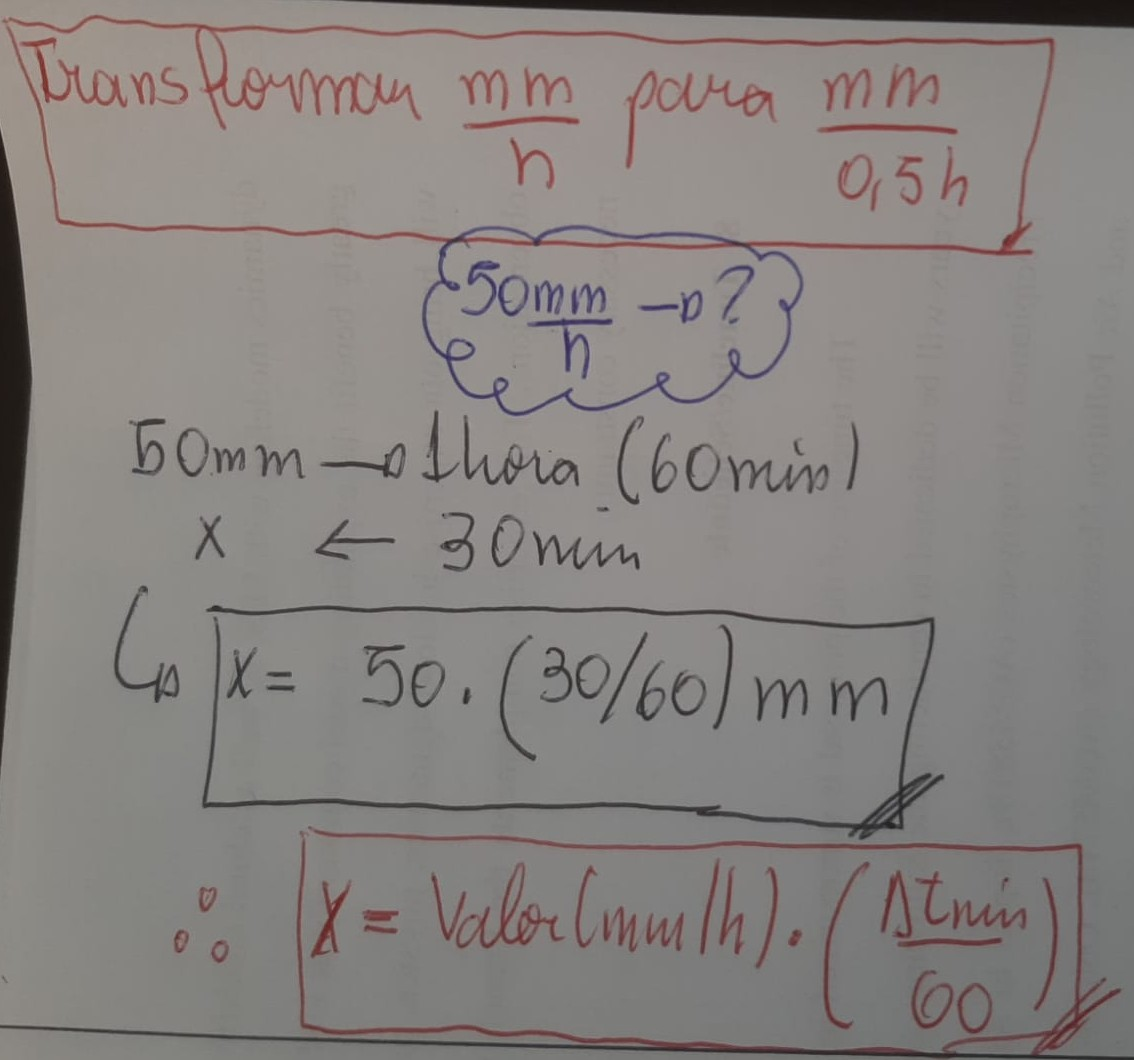

- Somando a precipitação de todas as imagens de radar num determinado período de tempo.

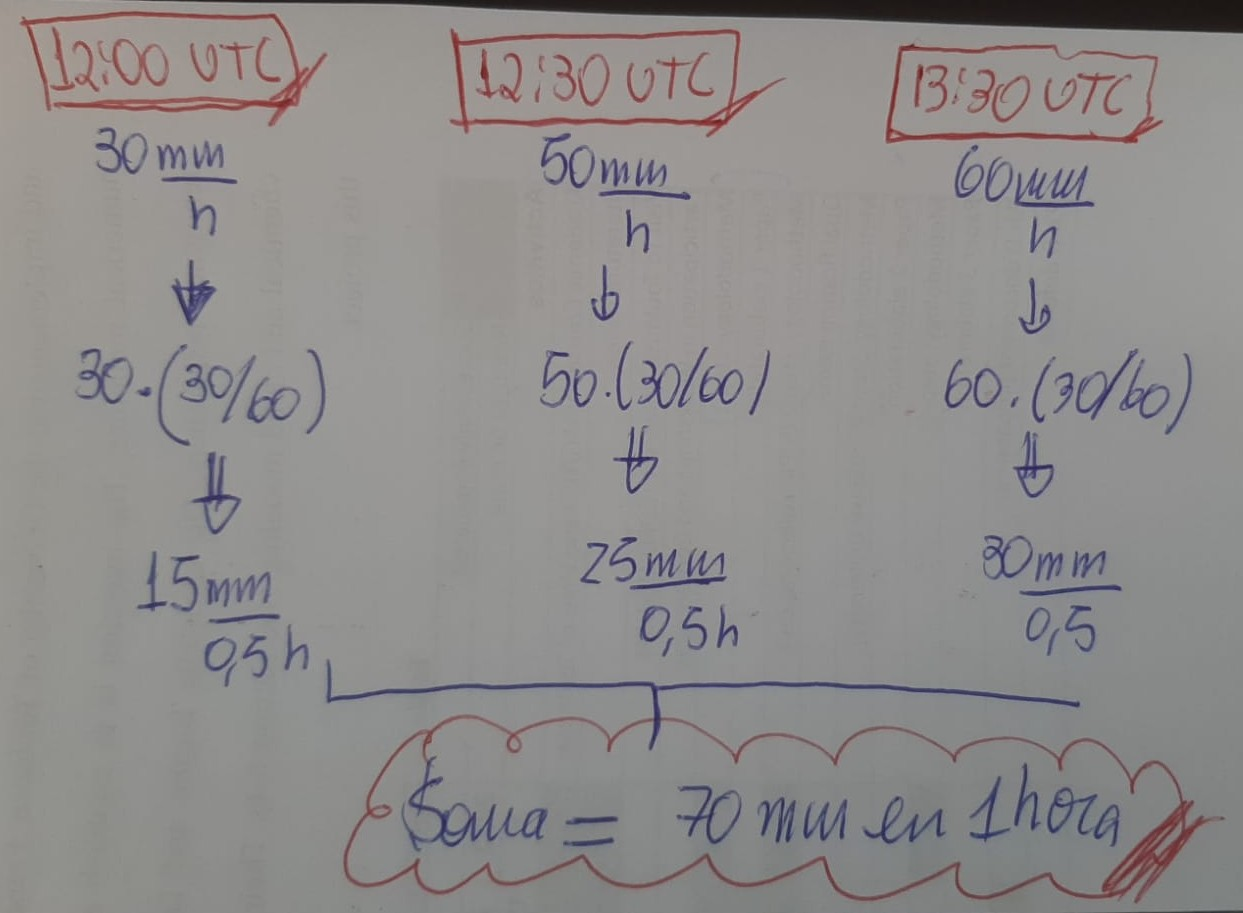

In [ ]:
#========================================================================================================================#
#                                                 DIRETÓRIOS
#========================================================================================================================#
# diretório de entrada
dir_input = f'{diretorio}/output/arquivos_netcdf'

# diretório de saída
dir_output = f'{diretorio}/output/arquivos_netcdf'

#========================================================================================================================#
#                                                 DEFINIÇÕES INICIAIS
#========================================================================================================================#
# frequência temporal do radar em minutos
frequencia_temporal_radar = 5.0

# conversão de 1h para 5.0min
fator = frequencia_temporal_radar / 60.

# escolha a estimativa de chuva
#estimativa_chuva = 'rainrate_z'
#estimativa_chuva = 'rainrate_kdp'
#estimativa_chuva = 'rainrate_z_kdp'
estimativa_chuva = 'rainrate_z_zdr_kdp'

# inicializa a variável de soma da chuva
chuva_total = np.zeros([500,500])

#========================================================================================================================#
#                                         LEITURA E SOMA DA PRECIPITAÇÃO
#========================================================================================================================#
# lista dos arquivos
files = sorted(glob.glob(f'{dir_input}/cappi_3000m_*.nc')) # Exemplo: cappi_3000m_FCTH_20230323_212116.nc

# loop dos arquivos
for file in files:

    print('PROCESSANDO ===>>', file)

    # leitura do arquivo netcdf
    ds = xr.open_dataset(file)

    # transforma "NaN" para "0.0"
    chuva_atual = ds[estimativa_chuva][:,:]
    chuva_atual = np.where(~np.isnan(chuva_atual), chuva_atual, 0.0)

    # soma total de chuva
    chuva_total = chuva_total + (chuva_atual*fator)

    # fechamento o arquivo
    ds.close()

#========================================================================================================================#
#                                              GERA ARQUIVO NETCDF
#========================================================================================================================#
# define encoding para compactação dos dados
encoding = {'rain_acumulado_dia': {'zlib': True}}

# define as variáveis
data_vars = {'rain_acumulado_dia': (('lat', 'lon'),
                                    chuva_total,
                                    {'units': 'mm/dia', 'long_name': 'Acumulado de Precipitação por Dia', '_FillValue': 0})}

# coordenadas
coords = {'lat': ds['lat'].values, 'lon': ds['lon'].values}

# atributos
descricao = "Constant Altitude Plan Position Indicator (CAPPI) de precipitação em 3 km de altitude com resolução espacial horizontal de 1 km para o radar da FCTH (SP)"
attrs = {'description': descricao,
         'creation_data': str(datetime.now()),
         'author':'Enrique V. Mattos',
         'email': 'enrique@unifei.edu.br'}

# gera Dataset
dataset = xr.Dataset(data_vars = data_vars, coords = coords, attrs = attrs)

# salva arquivo netcdf
dataset.to_netcdf(f'{dir_output}/chuva_acumulada_FCTH_{estimativa_chuva}.nc',  encoding=encoding)

In [ ]:
# exemplo do arquivo NETCDF gerado
ds = xr.open_dataset(f'{dir_output}/chuva_acumulada_FCTH_{estimativa_chuva}.nc')
ds

In [ ]:
ds['rain_acumulado_dia'][:,:].plot(figsize=(9,7), cmap='NWSRef', vmin=0, vmax=100)

## 5) Plota cappi da chuva acumulada

In [ ]:
#========================================================================================================================#
#                                              DEFINIÇÕES INICIAIS
#========================================================================================================================#
# diretório de entrada
dir_input = f'{diretorio}/output/arquivos_netcdf'

# diretório de saída
dir_output = f'{diretorio}/output'

# localização do radar
lat_radar, lon_radar = -23.600795, -45.97279

# leitura dos arquivos
chuva_dia = xr.open_dataset(f'{dir_input}/chuva_acumulada_FCTH_rainrate_z_zdr_kdp.nc')

# cria moldura da figura
fig, ax = uplt.subplots(figsize=(7,6), tight=True, proj='pcarree')

# exatrai os limites dos dados de CAPPI
lonmin, lonmax, latmin, latmax = float(ds['lon'].min()), float(ds['lon'].max()), float(ds['lat'].min()), float(ds['lat'].max())

# ou, se quiser uma área com zoom
lonmin, lonmax, latmin, latmax = -47.5, -44.5, -25, -22.2

# formatação dos eixos
ax.format(coast=False, borders=False, innerborders=False,
          labels=True,
          latlines=1.0, lonlines=1.0,
          title = f'{estimativa_chuva}',
          latlim=(latmin, latmax),
          lonlim=(lonmin, lonmax),
          small='20px',
          large='15px',
          abc=False)

#========================================================================================================================#
#                                                    PLOTA O MAPA
#========================================================================================================================#
map1 = ax.contourf(chuva_dia['lon'],
                   chuva_dia['lat'],
                   chuva_dia['rain_acumulado_dia'][:,:],
                   cmap='LangRainbow12',
                   levels=uplt.arange(0.1, 100., 5),
                   vmin=1, vmax=130)

#========================================================================================================================#
#                                           ANEIS DE DISTÂNCIA DO RADAR
#========================================================================================================================#
plota_aneis_distancia([50], lon_radar, lat_radar, 'gray', '100 km', ax)
plota_aneis_distancia([130], lon_radar, lat_radar, 'gray', '100 km', ax)

#========================================================================================================================#
#                                          PLOTA SHAPEFILES DOS ESTADOS
#========================================================================================================================#
estados_brasil = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/refs/heads/main/estados_do_brasil/BR_UF_2019.shp')
estados_selecionados = estados_brasil.loc[ (estados_brasil['SIGLA_UF'] == 'SP' ) | (estados_brasil['SIGLA_UF'] == 'RJ') | (estados_brasil['SIGLA_UF'] == 'MG')]
estados_selecionados.plot(edgecolor='gray', facecolor='none', linewidth=1.0, alpha=1, ax=ax)

#========================================================================================================================#
#                                         BARRA DE CORES E LEGENDA
#========================================================================================================================#
fig.colorbar(map1, loc='r', label='Precipitação (mm/dia)', ticks=10, ticklabelsize=15, labelsize=15, width=0.20, space=0.8, length=0.92)

# adiciona legenda
ax.legend(loc='lr', ncols=1, frameon=False, prop={'size':7.5}, markerscale=0.4)

#========================================================================================================================#
#                                              SALVA FIGURA
#========================================================================================================================#
fig.save(f'{dir_output}/Aula_11_chuva_acumulada_FCTH_{estimativa_chuva}.jpg', dpi=300)

#**AULA 12** - CLASSIFICAÇÃO DE HIDROMETEOROS - `AULA DE HOJE`

Iremos realizar a classificação de hidrometeoros para uma imagem de PPI. Para isto utilizaremos a função do Py-Art denominada [hydroclass_semisupervised](https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.hydroclass_semisupervised.html). A classificação gera as seguintes classes de `tipos` de hidrometeoros:

- 0: Not classified (NC)
- 1: Aggregates (AG)
- 2: Ice crystals (CR)
- 3: Light rain (LR)
- 4: Rimed particles (RP)
- 5: Rain (RN)
- 6: Vertically oriented ice (VI)
- 7: Wet snow (WS)
- 8: Melting hail (MH)
- 9: Dry hail or high-density graupel (IH e HDG)

## Baixando o arquivo do radar

In [ ]:
# nome do arquivo
filename = 'PNOVA2-20230218230002.HDF5'

# baixa o arquivo do radar
!wget {url}raw/main/input/{filename}

## Baixando os dados necessários para sondagens

- Iremos baixar o arquivo de sondagem da data `2023-02-18 às 12 UTC`. Este arquivo foi baixado da Universidade de [*Wyoming University*](https://weather.uwyo.edu/upperair/sounding.shtml) e colocado no [GitHub](https://github.com/evmpython/CAT016_2025) da nossa disciplina.

- Iremos baixar também do [GitHub](https://github.com/evmpython/CAT016_2025) da nossa disciplina um código python que faz a leitura dos dados de radiossondagem explicado acima.  

In [ ]:
!wget {url}raw/main/input/SMBT_20230218_12Z.txt
!wget {url}raw/main/input/le_sondagem_wyoming.py

## Carregando funções

In [ ]:
#========================================================================================================================#
#                                                IMPORTA BIBLIOTECAS
#========================================================================================================================#
import matplotlib.pyplot as plt
import matplotlib as mpl
import pyart
import numpy as np
import numpy.ma as ma

#========================================================================================================================#
#                                                      FUNÇÕES
#========================================================================================================================#
# Iremos definir funções para interpolar a radiossonda para a grade do radar
# essas funcoes foram criadas por Camila Lopes https://github.com/cclopes/

from le_sondagem_wyoming import Sounding

def radar_coords_to_cart(rng, az, ele, debug=False):

    theta_e = ele * np.pi / 180.0  # elevation angle in radians.
    theta_a = az * np.pi / 180.0  # azimuth angle in radians.
    R = 6371.0 * 1000.0 * 4.0 / 3.0  # effective radius of earth in meters.
    r = rng * 1000.0  # distances to gates in meters.

    z = (r ** 2 + R ** 2 + 2.0 * r * R * np.sin(theta_e)) ** 0.5 - R
    s = R * np.arcsin(r * np.cos(theta_e) / (R + z))  # arc length in m.
    x = s * np.sin(theta_a)
    y = s * np.cos(theta_a)
    return x, y, z

def get_z_from_radar(radar):

    azimuth_1D = radar.azimuth['data']
    elevation_1D = radar.elevation['data']
    srange_1D = radar.range['data']
    sr_2d, az_2d = np.meshgrid(srange_1D, azimuth_1D)
    el_2d = np.meshgrid(srange_1D, elevation_1D)[1]
    xx, yy, zz = radar_coords_to_cart(sr_2d/1000.0, az_2d, el_2d)
    return zz + radar.altitude['data']

def check_sounding_for_montonic(sounding):

    snd_T = sounding.soundingdata['temp']  # In old SkewT, was sounding.data
    snd_z = sounding.soundingdata['hght']  # In old SkewT, was sounding.data
    dummy_z = []
    dummy_T = []
    if not snd_T.mask[0]: #May cause issue for specific soundings
        dummy_z.append(snd_z[0])
        dummy_T.append(snd_T[0])
        for i, height in enumerate(snd_z):
            if i > 0:
                if snd_z[i] > snd_z[i-1] and not snd_T.mask[i]:
                    dummy_z.append(snd_z[i])
                    dummy_T.append(snd_T[i])
        snd_z = np.array(dummy_z)
        snd_T = np.array(dummy_T)
    return snd_T, snd_z

def interpolate_sounding_to_radar(sounding, radar):

    radar_z = get_z_from_radar(radar)
    snd_T, snd_z = check_sounding_for_montonic(sounding)

    # remover os valores com masked = True para nao gerar erro na interpolacao
    nlevels = snd_z.shape[0]

    snd_temp_0 = np.zeros(nlevels)
    snd_altura_0 = np.zeros(nlevels)

    # cria uma mascara de zeros - valores nao serao omitidos quando sao 0 (False)
    mask = np.zeros(nlevels)
    snd_temp = ma.masked_array(snd_temp_0, mask=mask)
    snd_altura = ma.masked_array(snd_altura_0, mask=mask)

    for i in range(nlevels):

        snd_temp.data[i] = snd_T[i]
        snd_altura.data[i] = snd_z[i]

        # se um dos valores, ou de altura ou de temperatura forem invalidos,
        # mascara os 2 vetores
        if (snd_T.mask[i] or snd_T.mask[i]):
            snd_temp.mask[i] = True
            snd_altura.mask[i] = True

    # exclui os valores mascarados do vetor, senao a interpolacao nao funciona
    snd_temp = snd_temp[~snd_temp.mask]
    snd_altura = snd_altura[~snd_altura.mask]

    # interpola a sondagem (1D) para o campo 3D do radar
    shape = np.shape(radar_z)
    rad_z1d = radar_z.ravel()
    rad_T1d = np.interp(rad_z1d, snd_altura, snd_temp)

    return np.reshape(rad_T1d, shape), radar_z
###############################################################################

## Plota figura

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

# latitudes e longitudes dos dados
lats = radar.gate_latitude
lons = radar.gate_longitude

# definindo a extensão dos dados em termos de latitude/longitude
lonmin = lons['data'].min()
lonmax = lons['data'].max()
latmin = lats['data'].min()
latmax = lats['data'].max()

#========================================================================================================================#
#                                             CLASSIFICAÇÃO DE HIDROMETEOROS
#========================================================================================================================#
# lendo a sondagem
snd = Sounding('/content/SMBT_20230218_12Z.txt')

# interpolando a temperatura e altura da sondagem para a grade do radar.
# Para cada bin calcula a altura e temperatura
radar_T, radar_z = interpolate_sounding_to_radar(snd, radar)

# usaremos o campo de temperatura da sondagem como entrada na função
# de classificacao de hidrometeotoros. Para isso vamos incluir o campo de temperatura no objeto radar
radar.add_field_like('corrected_reflectivity', 'temperature', radar_T)
radar.fields['temperature']['units'] = 'deg (C)'
radar.fields['temperature']['standard_name'] = 'temperature'
radar.fields['temperature']['long_name'] = 'interpolated sounding temperature'

# gerando a classificação
hclass = pyart.retrieve.hydroclass_semisupervised(radar,
                                                  refl_field='corrected_reflectivity',
                                                  zdr_field='corrected_differential_reflectivity',
                                                  rhv_field='cross_correlation_ratio',
                                                  kdp_field='specific_differential_phase',
                                                  temp_field='temperature')

# cria o dicionário no formato PyART
hclass_dict = {'data': hclass['hydro']['data'],
               'units': 'unitless',
               'long_name': 'Hydrometeor classification',
               'standard_name': 'radar_echo_classification',
               '_FillValue': -9999}

# adicionando o campo no objeto Radar
radar.add_field('radar_echo_classification', hclass_dict)

# classes geradas
# NC: Non-Classified
# AG: Aggregates
# CR: Crystals
# LR: Light rain
# RP: Rimed particles
# RN: Rain
# VI: Vertically oriented ice
# WS: Wet snow
# MH: Melting hail
# IH/HDG: Ice hail e high density graupel

#========================================================================================================================#
#                                                  PLOTA FIGURA
#========================================================================================================================#
# moldura da figura
fig = plt.figure(figsize=(8,6))

# cria o objeto display
display = pyart.graph.RadarDisplay(radar)

# define os labels da classificação
labels = ['NC','AG', 'CR', 'LR', 'RP', 'RN', 'VI', 'WS', 'MH', 'IH/HDG']
ticks = np.arange(len(labels))
boundaries = np.arange(-0.5, len(labels) )
norm = mpl.colors.BoundaryNorm(boundaries, 256)

# plota o mapa
display.plot_ppi('radar_echo_classification',
                 sweep=0,
                 norm=norm,
                 ticks=ticks,
                 ticklabs=labels,
                 colorbar_label='Classificação de Hidrometeoros')

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_12a_classif_{data}.jpg', dpi=300)

In [ ]:
print(radar_T.shape, radar_z.shape)

In [ ]:
radar_T

In [ ]:
radar_z

In [ ]:
radar.fields.keys()

In [ ]:
hclass

In [ ]:
hclass['hydro'].keys()

In [ ]:
hclass['hydro']['data']

## Vamos aprimorar o gráfico e adicionar o mapa de refletividade

In [ ]:
#========================================================================================================================#
#                                             LEITURA DO DADO DE RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

# latitudes e longitudes dos dados
lats = radar.gate_latitude
lons = radar.gate_longitude

# definindo a extensão dos dados em termos de latitude/longitude
lonmin = lons['data'].min()
lonmax = lons['data'].max()
latmin = lats['data'].min()
latmax = lats['data'].max()

#========================================================================================================================#
#                                             CLASSIFICAÇÃO DE HIDROMETEORO
#========================================================================================================================#
# lendo a sondagem
snd = Sounding('/content/SMBT_20230218_12Z.txt')

# interpolando a temperatura e altura da sondagem para a grade do radar
radar_T, radar_z = interpolate_sounding_to_radar(snd, radar)

# usaremos o campo de temperatura da sondagem como entrada na funcao
# de classificacao de hidrometeotoros. Para isso vamos incluir o campo temperatura no objeto radar
radar.add_field_like('corrected_reflectivity', 'temperature', radar_T)
radar.fields['temperature']['units'] = 'deg (C)'
radar.fields['temperature']['standard_name'] = 'temperature'
radar.fields['temperature']['long_name'] = 'interpolated sounding temperature'

# gerando a classificação
hclass = pyart.retrieve.hydroclass_semisupervised(radar,
                                                  refl_field='corrected_reflectivity',
                                                  zdr_field='corrected_differential_reflectivity',
                                                  rhv_field='cross_correlation_ratio',
                                                  kdp_field='specific_differential_phase',
                                                  temp_field='temperature')


# cria o dicionário no formato PyART
hclass_dict = {'data': hclass['hydro']['data'],
               'units': 'unitless',
               'long_name': 'Hydrometeor classification',
               'standard_name': 'radar_echo_classification',
               '_FillValue': -9999}

# adicionando o campo no objeto Radar
radar.add_field('radar_echo_classification', hclass_dict)

#========================================================================================================================#
#                                                  PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 3 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# moldura da figura
fig = plt.figure(figsize=(18,7))

# cria o objeto display
#display = pyart.graph.RadarDisplay(radar)
display = pyart.graph.RadarMapDisplay(radar)

#--------------------------#
#       FIGURA 1: ZH
#--------------------------#
# moldura da figura
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep=level,
                     vmin=0,
                     vmax=70,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     resolution='10m',
                     colorbar_label='Refletividade (dBZ)',
                     mask_outside=False,
                     ax=ax1,
                     cmap='NWSRef')

# plota as linhas de latitude e longitudes
ax1 = plt.gca()
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# título da figura
plt.title(f'PPI {str_level}$\degree$ - ZH: {data}', fontsize=10)
plt.title('a)', loc='left', fontsize=15)

# plota aneis de distância
display.plot_range_rings([100, 250], ax=ax1, col='gray', ls='--', lw=1)

#--------------------------#
# FIGURA 2: CLASSIFICAÇÃO
#--------------------------#
# moldura da figura
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())

# define os labels da classificação
labels = ['Non-Classified',
          'Aggregates',
          'Crystals',
          'Light rain',
          'Rimed particles',
          'Rain',
          'Vertically oriented ice',
          'Wet snow',
          'Melting hail',
          'Ice hail/high density Graupel']

ticks = np.arange(len(labels))
boundaries = np.arange(-0.5, len(labels) )
norm = mpl.colors.BoundaryNorm(boundaries, 256)

# plota o mapa
display.plot_ppi_map('radar_echo_classification',
                     sweep=3,
                     norm=norm,
                     ticks=ticks,
                     ticklabs=labels,
                     ax=ax2,
                     colorbar_label='',
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     resolution='10m',
                     mask_outside=False)

# plota as linhas de latitude e longitudes
ax2 = plt.gca()
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# título da figura
plt.title('Classificação de Hidrometeoros', fontsize=10)
plt.title('b)', loc='left', fontsize=10)

# plota aneis de distância
display.plot_range_rings([100, 250], ax=ax2, col='gray', ls='--', lw=1)

#================================================================================#
#                           SALVA FIGURA
#================================================================================#
# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_12b_classif_{data}.jpg', dpi=300)


---


**Realize as seguintes modificações:**
1. Mude a elevação.


---

#**AULA 13** - CLASSIFICAÇÃO CONVECTIVO/ESTATIFORME - `AULA DE HOJE`

Iremos realizar a classificação dos pixels da imagem em convectivo e estratiforme. Para isto utilizaremos a função do Py-Art denominada [conv_strat_yuter](https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.conv_strat_yuter.html).

## Baixando os dados

In [ ]:
# nome do arquivo
filename = 'PNOVA2-20230218230002.HDF5'

# baixa o arquivo do radar que esta no GitHub da nossa disciplina
!wget {url}raw/main/input/{filename}

## Plotando figura

In [ ]:
# mostrandos os atributos da função "retrieve.conv_strat_yuter"
pyart.retrieve.conv_strat_yuter?

In [ ]:
#========================================================================================================================#
#                                                LEITURA DADO DO RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a mais baixa elevação
radar = radar.extract_sweeps([0])

# extrai a latitude, longitude e altitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]
altitude = radar.altitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                GERA CAPPI
#========================================================================================================================#
# gera CAPPI
cappi = pyart.map.grid_from_radars(radar,
                                   grid_shape=(1, 500, 500),
                                   grid_limits=((3000.0 - altitude, 3000.0 - altitude),
                                                (-250000., 250000.),
                                                (-250000., 250000.)),
                                   grid_origin=(lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam',
                                   min_radius=1750.0,
                                   weighting_function='Nearest',
                                   fields=['corrected_reflectivity'])

# calcula a resolução em metros na dimensão x e y
dx = cappi.x["data"][1] - cappi.x["data"][0]
dy = cappi.y["data"][1] - cappi.y["data"][0]

#========================================================================================================================#
#                                        GERA CLASSIFICAÇÃO ESTRATIFORME/CONVECTIVO
#========================================================================================================================#
# classificação convectiva/estratiforme
convsf_dict = pyart.retrieve.conv_strat_yuter(cappi,
                                              dx,
                                              dy,
                                              refl_field="corrected_reflectivity",
                                              always_core_thres=40,
                                              bkg_rad_km=20,
                                              use_cosine=True,
                                              max_diff=3,
                                              zero_diff_cos_val=55,
                                              weak_echo_thres=5,
                                              max_conv_rad_km=2,
                                              estimate_flag=False)

# adiciona campo
cappi.add_field("feature_detection", convsf_dict["feature_detection"], replace_existing=True)

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 0 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# define o tamanho da figura
fig = plt.figure(figsize=(13, 5))

#==========================#
#     FIGURA 1: PPI
#==========================#
# define os eixos e projeção da figura
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())

# monta um objeto "display" do Py-ART
display = pyart.graph.GridMapDisplay(cappi)

# corrige o nível do cappi levando em conta a altitude do radar
# para mostrar corretamente no título da figura
display.grid.z['data'] = display.grid.z['data'] + altitude

# plota o cappi
display.plot_grid("corrected_reflectivity",
                  level=level,
                  vmin=0,
                  vmax=70,
                  ax=ax1,
                  cmap='NWSRef',
                  transform=ccrs.PlateCarree(),
                  colorbar_label='Refletividade (dBZ)')

# plotas as linhas passando pelo radar
display.plot_crosshairs(lon=lon_radar, lat=lat_radar, linewidth=1.0, color='black')

# nome dos eixos x e y
plt.xlabel('Longitude ($\degree$)')
plt.ylabel('Latitude ($\degree$)')

# título da figura
plt.title(f'CAPPI {int(display.grid.z["data"][0])} m: {data}', fontsize=10)
plt.title('a)', loc='left', fontsize=10)

#==========================#
# FIGURA 2: CLASSIFICAÇÃO
#==========================#
# moldura da figura
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())

# plota o mapa
display.plot_grid("feature_detection",
                  vmin=0,
                  vmax=2,
                  cmap=plt.get_cmap("viridis", 3),
                  transform=ccrs.PlateCarree(),
                  ticks=[1 / 3, 1, 5 / 3],
                  ticklabs=["Sem Classe", "Estratiforme", "Convectivo"],
                  ax=ax2)

# plotas as linhas passando pelo radar
display.plot_crosshairs(lon=lon_radar, lat=lat_radar, linewidth=1.0, color='black')

# nome dos eixos x e y
plt.xlabel('Longitude ($\degree$)')
plt.ylabel('Latitude ($\degree$)')

# título da figura
plt.title(f'Classificação convectivo/estratiforme', fontsize=10)
plt.title('b)', loc='left', fontsize=10)
#========================================================================================================================#

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_13_conv_strat_yuter_{data}.jpg', dpi=300)

In [ ]:
# mostra os valores das resoluções espaciais em metros
dx, dy

In [ ]:
# mostra o tipo da variável
type(convsf_dict)

In [ ]:
# mostra os valores
convsf_dict

In [ ]:
# mostra os valores
convsf_dict['feature_detection']

In [ ]:
# mostra os valores
convsf_dict['feature_detection'].keys()

In [ ]:
# mostra os valores
convsf_dict['feature_detection']['data']

In [ ]:
# mostra os valores
convsf_dict['feature_detection']['valid_min']

In [ ]:
# mostra os valores
convsf_dict['feature_detection']['valid_max']

#**AULA 14** - PERFIS VERTICAIS DE RADAR - `REALIZADA`

Para extrair o perfil vertical utilizaremos a função [get_field_location](https://arm-doe.github.io/pyart/API/generated/pyart.util.get_field_location.html).

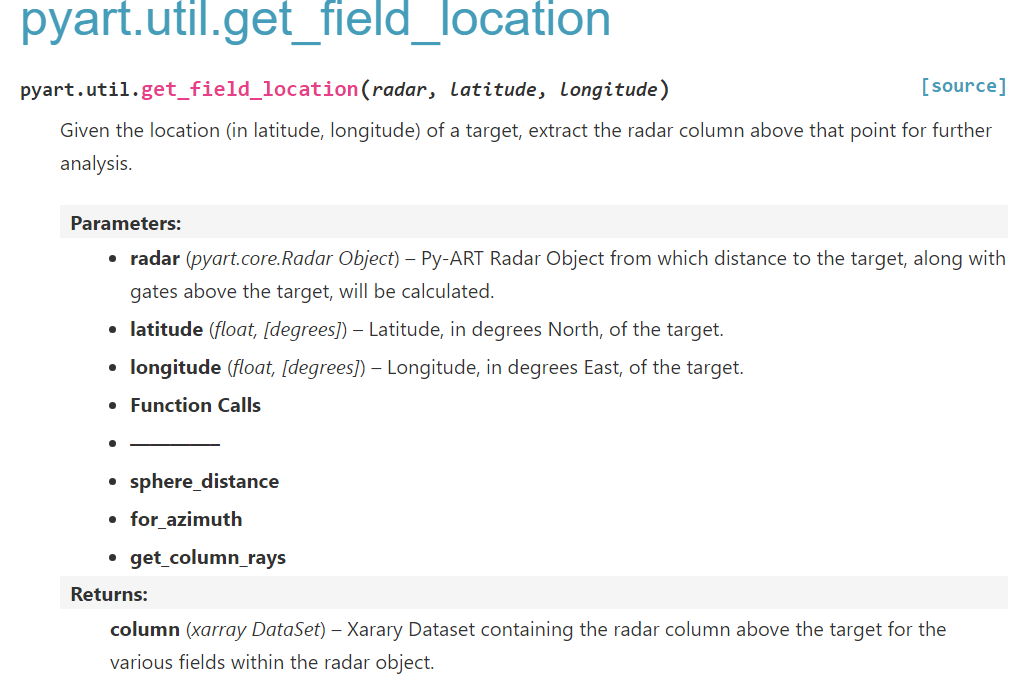

In [ ]:
#========================================================================================================================#
#                                                LEITURA DADO DO RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                               DEFINE LOCAL DO PERFIL
#========================================================================================================================#
# localização do ponto
site_lon = -45.25  # longitude em graus
site_lat = -23.98  # latitdue em graus

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define a elevação
level = 0 #(=primeira elevação)

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# cria moldura da figura
fig = plt.figure(figsize=[16,6])

#==========================#
#     FIGURA 1: PPI
#==========================#
# moldura da figura
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())

# cria o RadarMapDisplay e adiciona a projeção
display = pyart.graph.RadarMapDisplay(radar)

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep=level,
                     vmin=0,
                     vmax=70,
                     ax=ax1,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=ccrs.PlateCarree(central_longitude=lon_radar),
                     resolution='10m',
                     cmap='NWSRef',
                     colorbar_label='Refletividade (dBZ)',
                     min_lon=-46,
                     max_lon=-45,
                     min_lat=-24.2,
                     max_lat=-23.5)

# plota a localização do ponto do perfil vertical
ax1.scatter(site_lon, site_lat, color='black', marker='X', s=80)

# plota as linhas perpendiculares que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray', ax=ax1)

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota as linhas de latitude e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# título da figura
plt.title(f'PPI {str_level}$\degree$: {data} UTC', fontsize=15)
plt.title('a)', loc='left', fontsize=15)

#==========================#
#     FIGURA 2: PERFIL
#==========================#
# moldura da figura
ax2 = plt.subplot(122)

# extrai o perfil vertical
ds = pyart.util.columnsect.get_field_location(radar, site_lat, site_lon)

# plota o gráfico
ds['corrected_reflectivity'].plot(y="height")

# nome dos eixos x e y
plt.xlabel('Refletividade (dBZ)')
plt.ylabel('Altura (m)')

# título figura
plt.title(f'Perfil Vertical', fontsize=15)
plt.title('b)', loc='left', fontsize=15)

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_14a_perfil_{data}.jpg', dpi=300)

Verificando a variável `ds`produzida do perfil vertical

In [ ]:
ds

Vamos gerar e plotar o corte vertical para as quatro variáveis: ZH, ZDR, KDP e COR.

In [ ]:
#========================================================================================================================#
#                                                LEITURA DADO DO RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                               GERA PERFIL VERTICAL
#========================================================================================================================#
# localização do ponto
site_lon = -45.25  # longitude em graus
site_lat = -23.98  # latitdue em graus

# extrae o perfil vertical
ds = pyart.util.columnsect.get_field_location(radar, site_lat, site_lon)

#========================================================================================================================#
#                                                          ZH
#========================================================================================================================#
# cria moldura da figura
fig = plt.figure(figsize=[13,15])

#--------------------------#
#     FIGURA 1: PPI
#--------------------------#
# moldura da figura
ax1 = plt.subplot(421, projection=ccrs.PlateCarree())

# cria o RadarMapDisplay e adiciona a projeção
display = pyart.graph.RadarMapDisplay(radar)

# plota o mapa
display.plot_ppi_map('corrected_reflectivity',
                     sweep=level,
                     vmin=0,
                     vmax=70,
                     ax=ax1,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=ccrs.PlateCarree(central_longitude=lon_radar),
                     resolution='10m',
                     cmap='NWSRef',
                     colorbar_label='Refletividade (dBZ)',
                     mask_outside=False,
                     min_lon=-46,
                     max_lon=-45,
                     min_lat=-24.2,
                     max_lat=-23.5)

# plota a localização do ponto do perfil vertical
ax1.scatter(site_lon, site_lat, color='black', marker='X', s=80)

# plota as linhas perpendiculares que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray', ax=ax1)

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota as linhas de latitude e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# título da figura
plt.title(f'PPI {str_level}$\degree$ - ZH: {data} UTC', fontsize=10)
plt.title('a)', loc='left', fontsize=15)

#--------------------------#
#     FIGURA 2: PERFIL
#--------------------------#
# moldura da figura
ax2 = plt.subplot(422)

# plota o gráfico
ds['corrected_reflectivity'].plot(y="height")

# nome dos eixos x e y
plt.xlabel('Refletividade (dBZ)')
plt.ylabel('Altura (m)')

# título figura
plt.title(f'Perfil Vertical - ZH', fontsize=10)
plt.title('b)', loc='left', fontsize=10)

#========================================================================================================================#
#                                                          ZDR
#========================================================================================================================#
#--------------------------#
#     FIGURA 1: PPI
#--------------------------#
# moldura da figura
ax3 = plt.subplot(423, projection=ccrs.PlateCarree())

# cria o RadarMapDisplay e adiciona a projeção
display = pyart.graph.RadarMapDisplay(radar)

# plota o mapa
display.plot_ppi_map('corrected_differential_reflectivity',
                     sweep=level,
                     vmin=-2,
                     vmax=6,
                     ax=ax3,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=ccrs.PlateCarree(central_longitude=lon_radar),
                     resolution='10m',
                     colorbar_label='Refletividade Diferencial (dB)',
                     mask_outside=False,
                     min_lon=-46,
                     max_lon=-45,
                     min_lat=-24.2,
                     max_lat=-23.5)

# plota a localização do ponto do perfil vertical
ax3.scatter(site_lon, site_lat, color='black', marker='X', s=80)

# plota as linhas perpendiculares que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray', ax=ax1)

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota as linhas de latitude e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# título da figura
plt.title(f'PPI {str_level}$\degree$ - ZDR: {data} UTC', fontsize=10)
plt.title('C)', loc='left', fontsize=10)

#--------------------------#
#     FIGURA 2: PERFIL
#--------------------------#
# moldura da figura
ax4 = plt.subplot(424)

# plota o gráfico
ds['corrected_differential_reflectivity'].plot(y="height")

# nome dos eixos x e y
plt.xlabel('Refletividade Diferencial (dB)')
plt.ylabel('Altura (m)')

# título figura
plt.title(f'Perfil Vertical - ZDR', fontsize=10)
plt.title('d)', loc='left', fontsize=10)

#========================================================================================================================#
#                                                          KDP
#========================================================================================================================#
#--------------------------#
#     FIGURA 1: PPI
#--------------------------#
# moldura da figura
ax5 = plt.subplot(425, projection=ccrs.PlateCarree())

# cria o RadarMapDisplay e adiciona a projeção
display = pyart.graph.RadarMapDisplay(radar)

# plota o mapa
display.plot_ppi_map('specific_differential_phase',
                     sweep=level,
                     vmin=-2,
                     vmax=6,
                     ax=ax5,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=ccrs.PlateCarree(central_longitude=lon_radar),
                     resolution='10m',
                     colorbar_label='Fase Diferencial Específica ($\degree$/km)',
                     mask_outside=False,
                     min_lon=-46,
                     max_lon=-45,
                     min_lat=-24.2,
                     max_lat=-23.5)

# plota a localização do ponto do perfil vertical
ax5.scatter(site_lon, site_lat, color='black', marker='X', s=80)

# plota as linhas perpendiculares que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray', ax=ax1)

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota as linhas de latitude e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# título da figura
plt.title(f'PPI {str_level}$\degree$ - KDP: {data} UTC', fontsize=10)
plt.title('e)', loc='left', fontsize=15)

#--------------------------#
#     FIGURA 2: PERFIL
#--------------------------#
# moldura da figura
ax6 = plt.subplot(426)

# plota o gráfico
ds['specific_differential_phase'].plot(y="height")

# nome dos eixos x e y
plt.xlabel('Fase Diferencial Específica ($\degree$/km)')
plt.ylabel('Altura (m)')

# título figura
plt.title(f'Perfil Vertical - KDP', fontsize=10)
plt.title('f)', loc='left', fontsize=10)

#========================================================================================================================#
#                                                          COR
#========================================================================================================================#
#--------------------------#
#     FIGURA 1: PPI
#--------------------------#
# moldura da figura
ax7 = plt.subplot(427, projection=ccrs.PlateCarree())

# cria o RadarMapDisplay e adiciona a projeção
display = pyart.graph.RadarMapDisplay(radar)

# plota o mapa
display.plot_ppi_map('cross_correlation_ratio',
                     sweep=level,
                     vmin=0.7,
                     vmax=1,
                     ax=ax7,
                     lat_0=lat_radar,
                     lon_0=lon_radar,
                     projection=ccrs.PlateCarree(central_longitude=lon_radar),
                     resolution='10m',
                     colorbar_label='Coeficiente de Correlação (#)',
                     mask_outside=False,
                     min_lon=-46,
                     max_lon=-45,
                     min_lat=-24.2,
                     max_lat=-23.5)

# plota a localização do ponto do perfil vertical
ax7.scatter(site_lon, site_lat, color='black', marker='X', s=80)

# plota as linhas perpendiculares que passam pelo centro do radar
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray', ax=ax1)

# indica a localização do radar com um ponto
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota as linhas de latitude e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# título da figura
plt.title(f'PPI {str_level}$\degree$ - RhoHV: {data} UTC', fontsize=10)
plt.title('g)', loc='left', fontsize=10)

#--------------------------#
#     FIGURA 2: PERFIL
#--------------------------#
# moldura da figura
ax8 = plt.subplot(428)

# plota o gráfico
ds['cross_correlation_ratio'].plot(y="height")

# nome dos eixos x e y
plt.xlabel('Coeficiente de Correlação (#)')
plt.ylabel('Altura (m)')

# título figura
plt.title(f'Perfil Vertical - RhoHV', fontsize=10)
plt.title('h)', loc='left', fontsize=10)
#========================================================================================================================#

# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_14b_perfil_{data}.jpg', dpi=300)

#**AULA 15** - COMBINAÇÃO DE DADOS DE RADAR COM RELÂMPAGOS - `REALIZADA`

Definindo as funções para baixar os dados do GLM

In [ ]:
# Instalando o boto3 (usado para baixar os dados da Amazon)
!pip install boto3 -q

from datetime import timedelta, date, datetime
import boto3                             # Amazon Web Services (AWS) SDK for Python
from botocore import UNSIGNED            # boto3 config
from botocore.config import Config       # boto3 config

#-----------------------------------------------------------------------------------
# Função que baixa os dados do GLM (GOES-16) no site de Amazon
#-----------------------------------------------------------------------------------
def download_GLM(yyyymmddhhmnss, path_dest):

    # caminho do ftp da Amazon
    #ftp_glm = https://noaa-goes16.s3.amazonaws.com/index.html#GLM-L2-LCFA/

    os.makedirs(path_dest, exist_ok=True)

    year = datetime.strptime(yyyymmddhhmnss, '%Y%m%d%H%M%S').strftime('%Y')
    day_of_year = datetime.strptime(yyyymmddhhmnss, '%Y%m%d%H%M%S').strftime('%j')
    hour = datetime.strptime(yyyymmddhhmnss, '%Y%m%d%H%M%S').strftime('%H')
    min = datetime.strptime(yyyymmddhhmnss, '%Y%m%d%H%M%S').strftime('%M')
    seg = datetime.strptime(yyyymmddhhmnss, '%Y%m%d%H%M%S').strftime('%S')

    # AMAZON repository information
    # https://noaa-goes16.s3.amazonaws.com/index.html
    bucket_name = 'noaa-goes16'

    # Initializes the S3 client
    s3_client = boto3.client('s3', config=Config(signature_version=UNSIGNED))
    #-----------------------------------------------------------------------------------------------------------
    # File structure
    product_name = "GLM-L2-LCFA"
    prefix = f'{product_name}/{year}/{day_of_year}/{hour}/OR_{product_name}_G16_s{year}{day_of_year}{hour}{min}{seg}'

    # Seach for the file on the server
    s3_result = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=prefix, Delimiter = "/")

    #-----------------------------------------------------------------------------------------------------------
    # Check if there are files available
    if 'Contents' not in s3_result:

        # There are no files
        print(f'No files found for the date: {yyyymmddhhmnss}, Product-{product_name}')
        return -1

    else:

        # There are files
        for obj in s3_result['Contents']:
            key = obj['Key']

        # Print the file name
        file_name = key.split('/')[-1].split('.')[0]

        # Download the file
        if os.path.exists(f'{path_dest}/{file_name}.nc'):
            print(f'File {path_dest}/{file_name}.nc exists')
        else:
            print(f'Downloading file {path_dest}/{file_name}.nc')
            s3_client.download_file(bucket_name, key, f'{path_dest}/{file_name}.nc')

    return f'{file_name}'

#-----------------------------------------------------------------------------------
# Função que baixa os dados do GLM (GOES-16) no site de Amazon num intervalo de 5 min
# centrado no horário da imagem de satélite
#-----------------------------------------------------------------------------------
def download_e_acumula_GLM(ano, mes, dia, hor, min):

    # define data inicial e final para acumular os relâmpagos
    date_ini = str(datetime(int(ano), int(mes), int(dia), int(hor), int(min)))
    date_end = str(datetime(int(ano), int(mes), int(dia), int(hor), int(min)) + timedelta(minutes=5)) # soma 5 minutos na data inicial

    # inicializa os arrays de latitude e longitude
    lats_event, lons_event = np.array([]), np.array([])
    lats_group, lons_group = np.array([]), np.array([])
    lats_flash, lons_flash = np.array([]), np.array([])

    # loop da acumulação de relâmpagos
    while (date_ini < date_end):

        # estrutura da data
        yyyymmddhhmnss = datetime.strptime(date_ini, '%Y-%m-%d %H:%M:%S').strftime('%Y%m%d%H%M%S')

        # baixando GLM
        file_glm = download_GLM(yyyymmddhhmnss, '/content')

        # leitura GLM
        ds = xr.open_dataset(f'/content/{file_glm}.nc')

        # apenda as lats/lons dos eventos, grupos e flashes
        lats_event = np.append(lats_event, ds['event_lat'])
        lons_event = np.append(lons_event, ds['event_lon'])

        lats_group = np.append(lats_group, ds['group_lat'])
        lons_group = np.append(lons_group, ds['group_lon'])

        lats_flash = np.append(lats_flash, ds['flash_lat'])
        lons_flash = np.append(lons_flash, ds['flash_lon'])

        # incrementa 20s no tempo
        date_ini = str(datetime.strptime(date_ini, '%Y-%m-%d %H:%M:%S') + timedelta(seconds=20))

    return lats_event, lons_event, lats_group, lons_group, lats_flash, lons_flash

In [ ]:
#========================================================================================================================#
#                                                LEITURA DADO DO RADAR
#========================================================================================================================#
# leitura do arquivo
filename = 'PNOVA2-20230218230002.HDF5'
radar = pyart.aux_io.read_gamic(f'/content/{filename}')

# extrai a latitude e longitude do radar
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

# limites dos dados
latmin, latmax = radar.gate_latitude['data'].min(), radar.gate_latitude['data'].max()
lonmin, lonmax = radar.gate_longitude['data'].min(), radar.gate_longitude['data'].max()

# extrai a data do dado do radar
data = pyart.util.datetime_from_grid(radar)

#========================================================================================================================#
#                                                    CAPPI
#========================================================================================================================#
# gera CAPPI
cappi = pyart.map.grid_from_radars(radar,
                                   grid_shape=(2, 500, 500),
                                   grid_limits=((3000. - altitude, 4000. -altitude),
                                                (-250000., 250000.),
                                                (-250000., 250000.)),
                                   grid_origin=(lat_radar, lon_radar),
                                   gridding_algo='map_gates_to_grid',
                                   roi_func='dist_beam',
                                   min_radius=1750.0,
                                   weighting_function='Nearest',
                                   fields=['corrected_reflectivity'])

#========================================================================================================================#
#                                                     PLOTA FIGURA
#========================================================================================================================#
# define o tamanho da figura
fig = plt.figure(figsize=(10,7))

# define os eixos e projeção da figura
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# monta um objeto "display" do Py-ART
display = pyart.graph.GridMapDisplay(cappi)

# corrige o nível do cappi levando em conta a altitude do radar
# para mostrar corretamente no título da figura
display.grid.z['data'] = display.grid.z['data'] + altitude

# plota o cappi
display.plot_grid("corrected_reflectivity",
                  level=0,
                  vmin=0,
                  vmax=70,
                  ax=ax,
                  cmap='NWSRef',
                  colorbar_label='Refletividade (dBZ)')

# plotas as linhas passando pelo radar
display.plot_crosshairs(lon=lon_radar, lat=lat_radar)

# Plota os aneis de distância do radar
evm_plota_aneis_em_geral([100, 250], lon_radar, lat_radar, 'black', label='Radar: 45 km')

# título da figura
plt.title(f'CAPPI {int(display.grid.z["data"][0])} m - Refletividade + Flash (GLM): {data}', fontsize=15)

# nome dos eixos x e y
ax.set_xlabel('Longitude ($\degree$)', fontsize=15)
ax.set_ylabel('Latitude ($\degree$)', fontsize=15)

#========================================================================================================================#
#                                          PLOTA RELÂMPAGOS DO GOES-16 (GLM)
#========================================================================================================================#
# extrai o ano, mes, dia, hora, min do radar
ano = str(pyart.util.datetime_from_grid(radar).year)
mes = str(pyart.util.datetime_from_grid(radar).month).zfill(2)
dia = str(pyart.util.datetime_from_grid(radar).day).zfill(2)
hor = str(pyart.util.datetime_from_grid(radar).hour).zfill(2)
min = str(pyart.util.datetime_from_grid(radar).minute).zfill(2)

# baixa os dados do GLM
lats_event, lons_event, lats_group, lons_group, lats_flash, lons_flash = download_e_acumula_GLM(ano, mes, dia, hor, min)

# plota flashes
ax.scatter(lons_flash, lats_flash, transform=ccrs.PlateCarree(), marker='x', s=40, color='blue', label=f'Flashes={len(lats_flash)}')

#========================================================================================================================#
#                                                   SALVA FIGURA
#========================================================================================================================#
# recorta figura
plt.tight_layout()

# salva figura
plt.savefig(f'{diretorio}/output/Aula_15b_cappi_relampagos_{data}.jpg', dpi=300)